In [1]:
import numpy as np
from astropy.io import fits
import stpsf
from astropy.nddata import Cutout2D
from tqdm import tqdm
from correction_script import find_stars, star_check, better_psf_fitting, plot_data_sim_comparison, sigma_clip

/home/wesley/Desktop/JWST_REU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [2]:
path_image = "/home/wesley/Desktop/JWST_REU/2026_data/"
file = '/home/wesley/Desktop/JWST_REU/2026_data/jwst-2026-f444w-f470n.fits'

In [3]:
hdu = fits.open((path_image + 'jwst-2026-f444w-f470n.fits'))

INFO: Query finished. [astroquery.utils.tap.core]


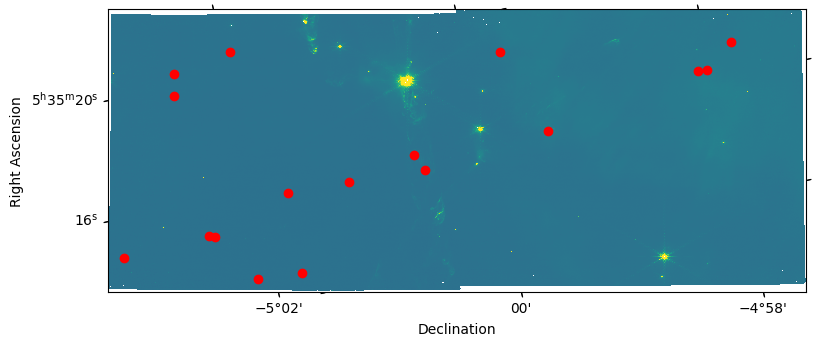

In [4]:
ra_center = hdu[1].header['CRVAL1']
dec_center = hdu[1].header['CRVAL2']
size_deg = .1
image = hdu[1].data
header = hdu[1].header

x_coords, y_coords, gaia_star_field = find_stars(ra_center, dec_center, size_deg, image, header)

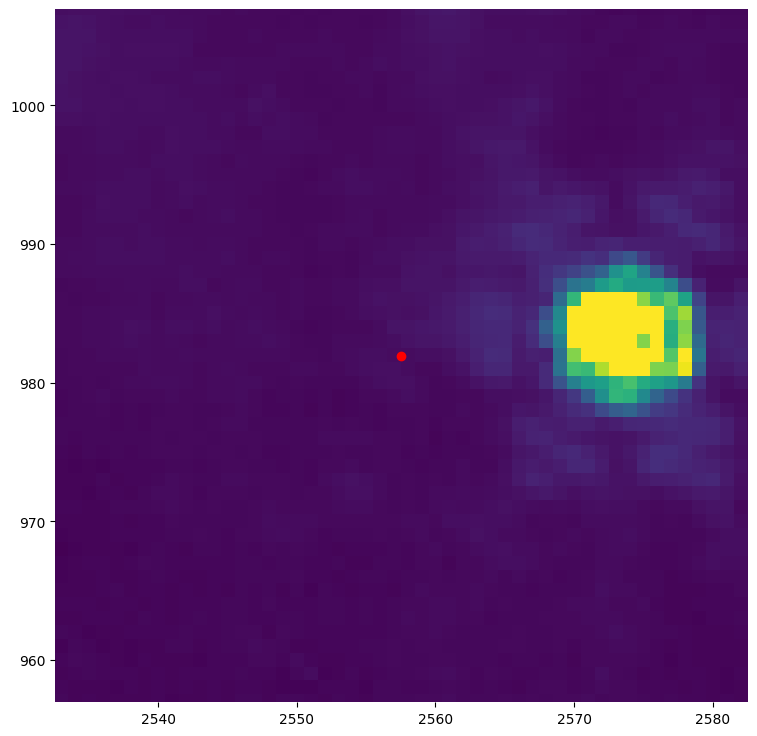

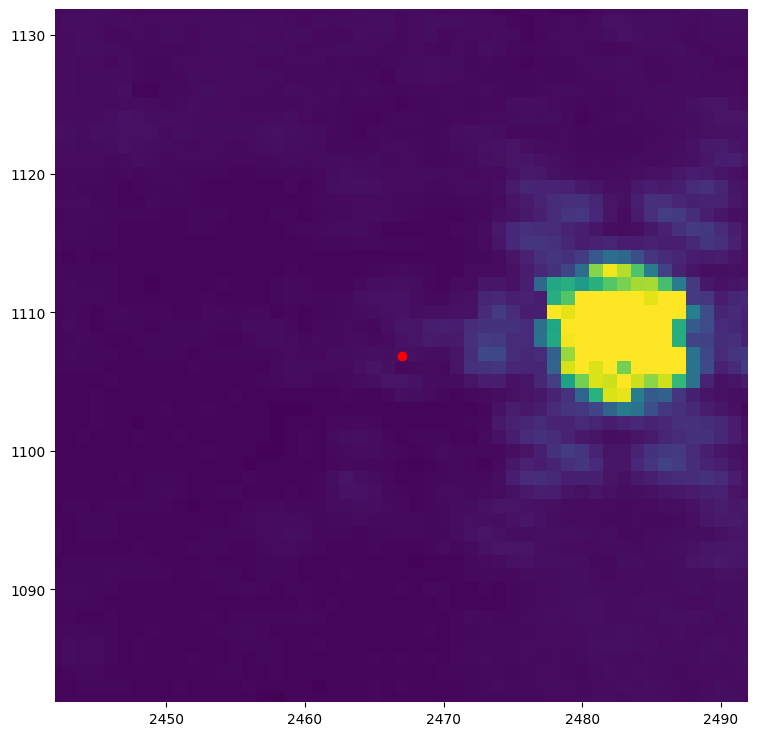

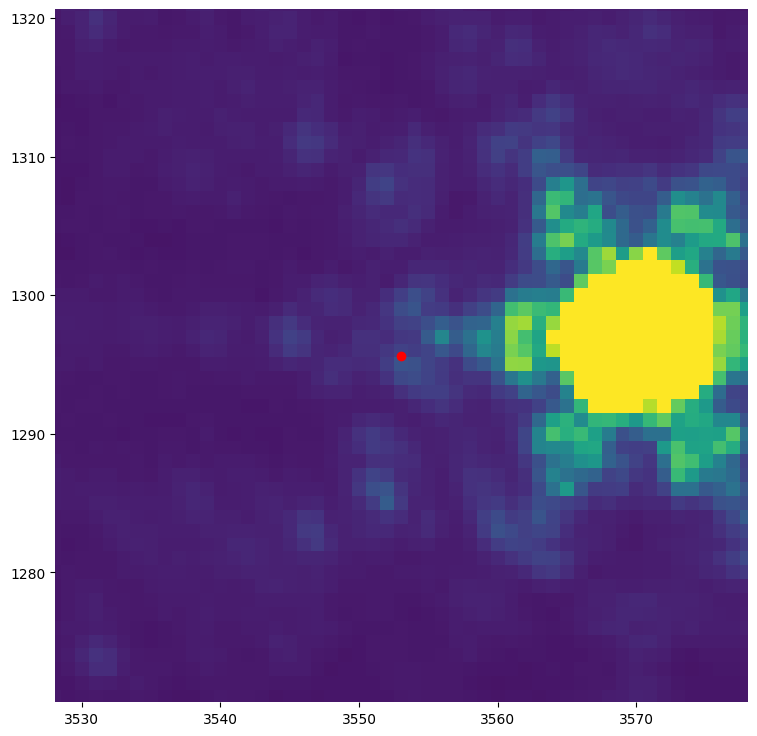

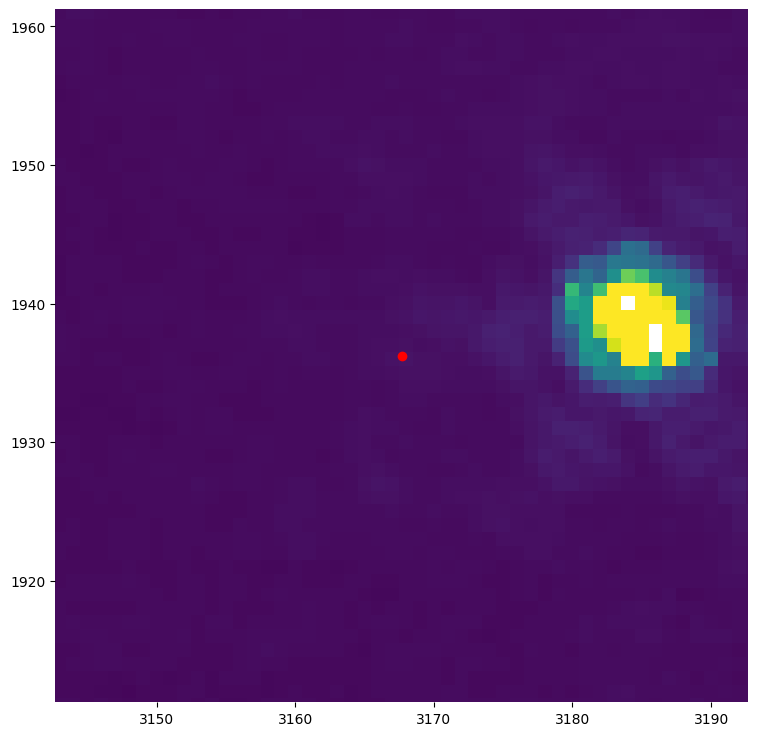

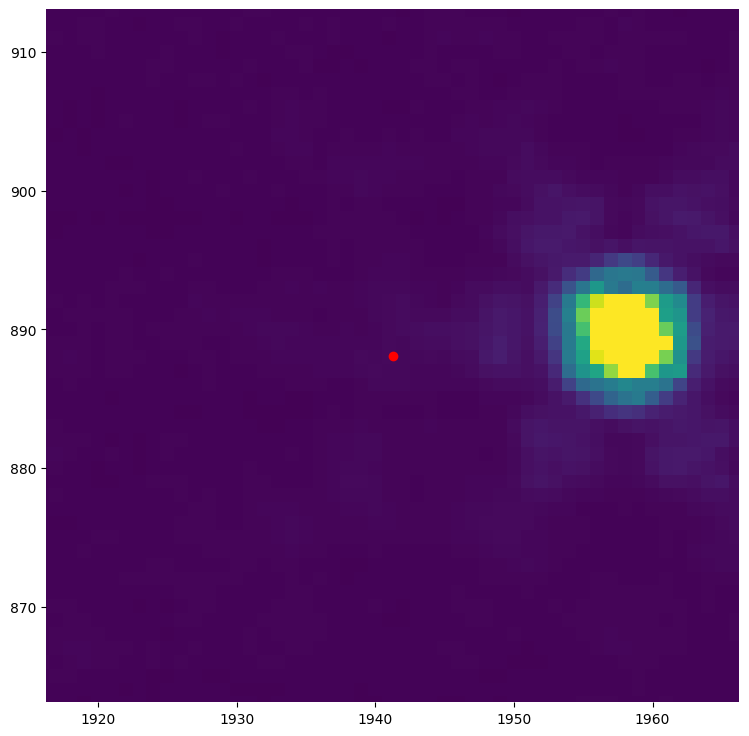

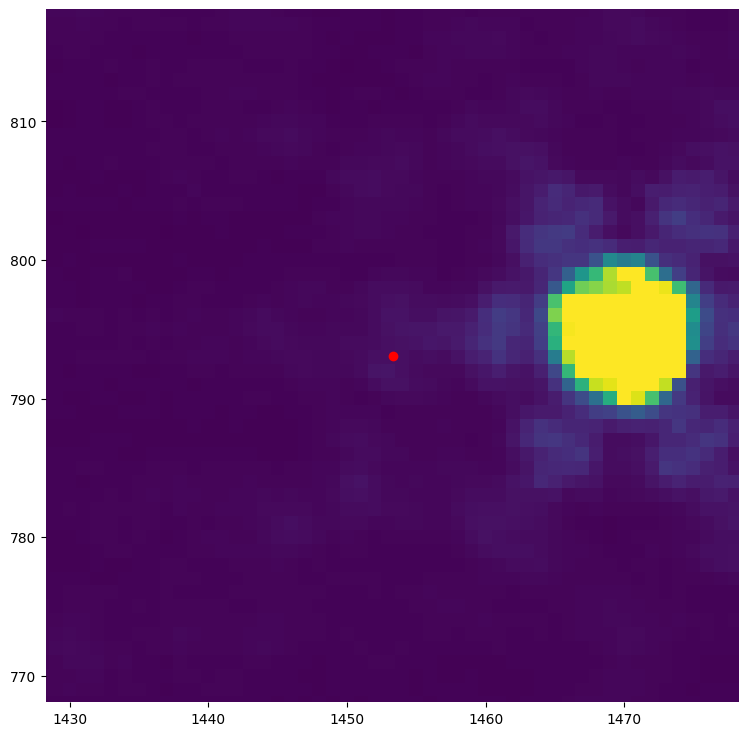

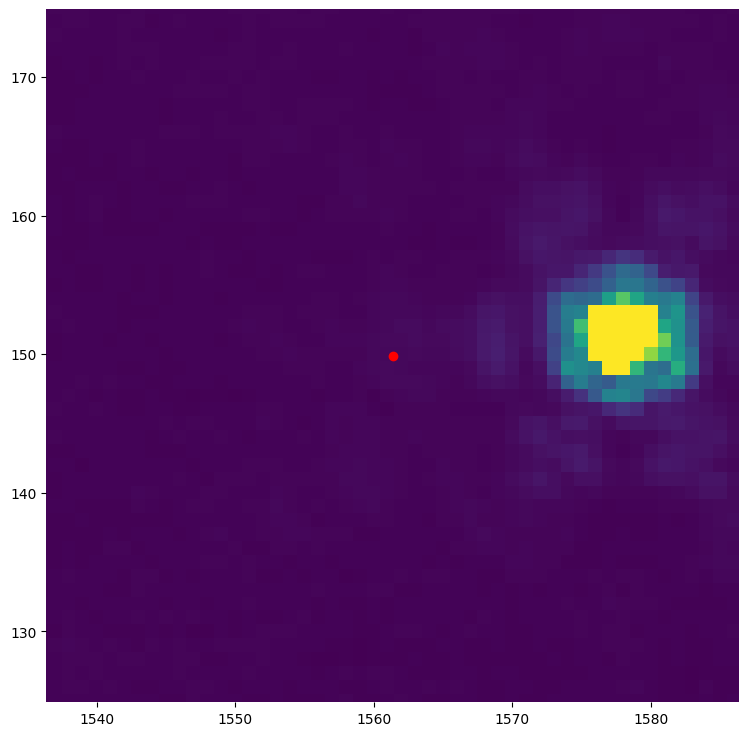

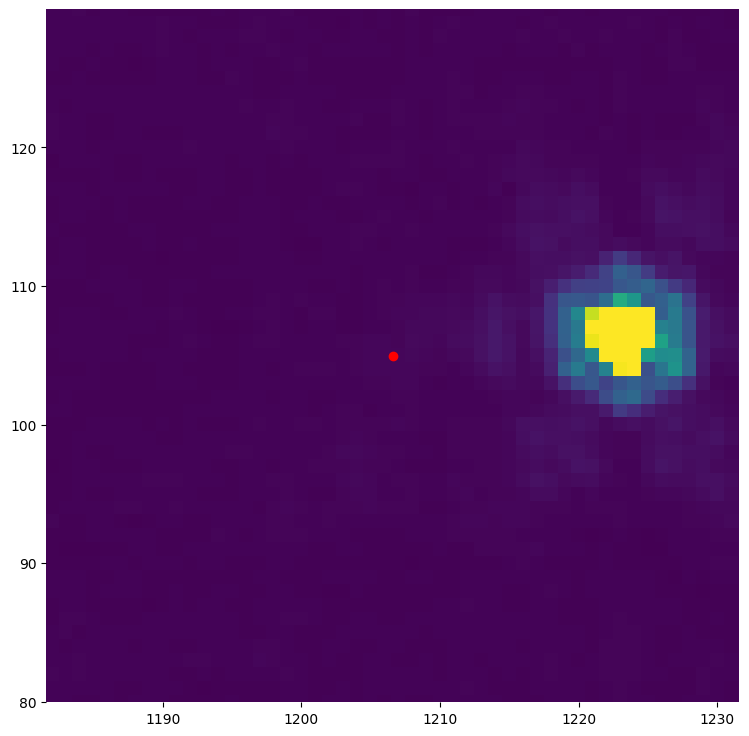

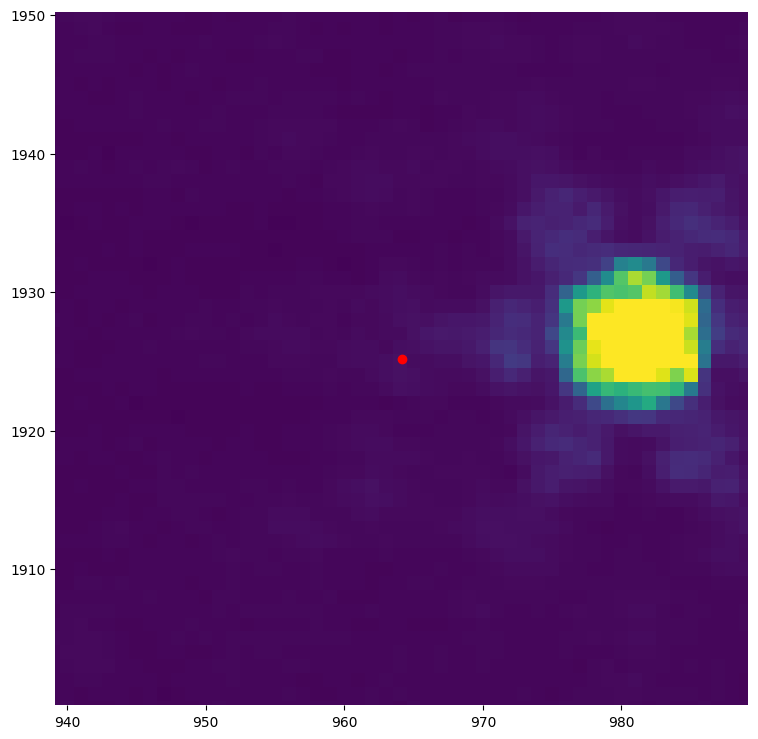

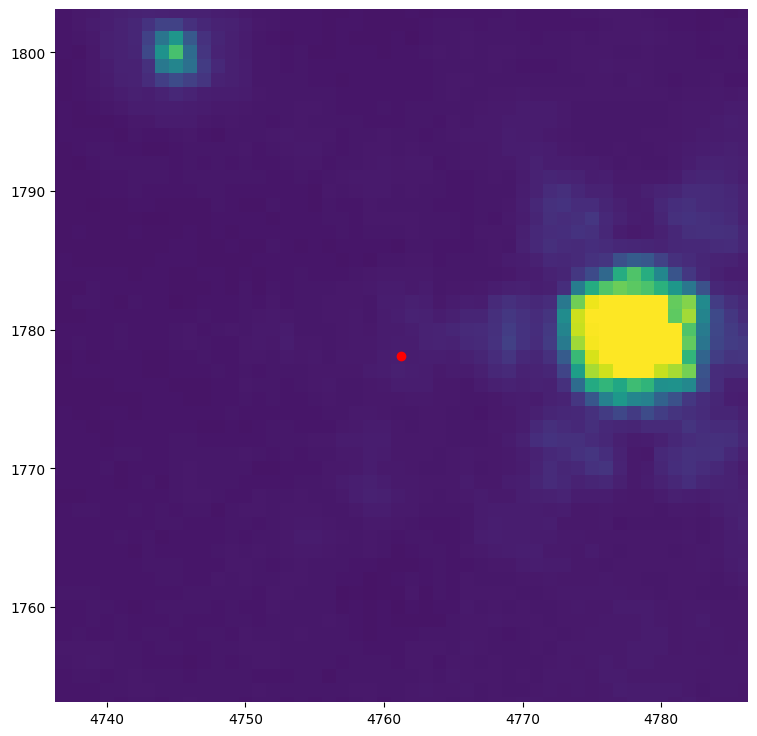

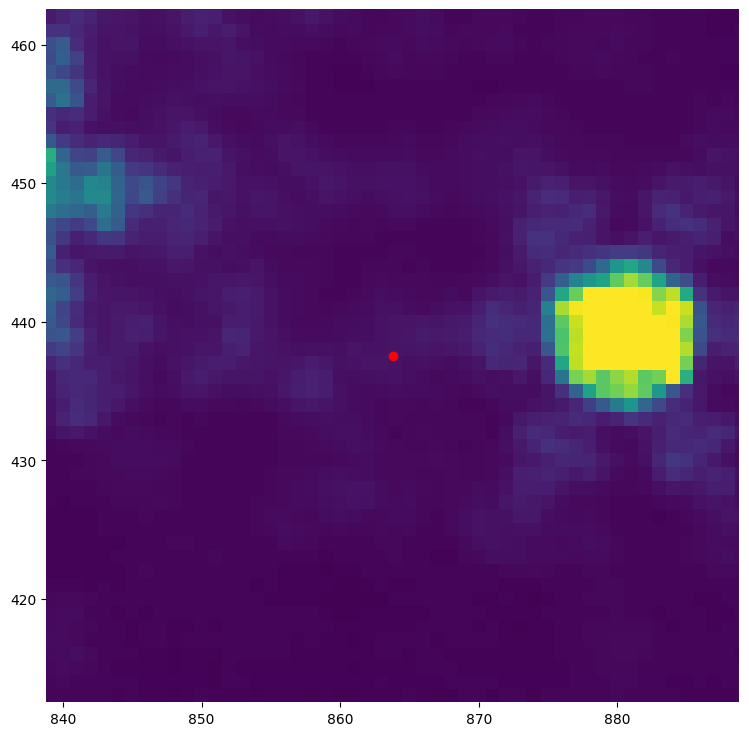

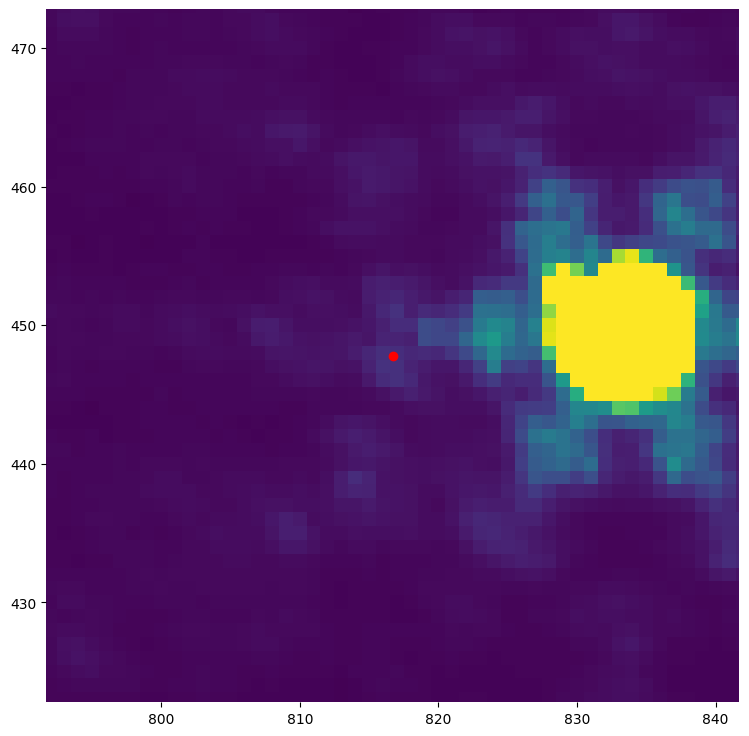

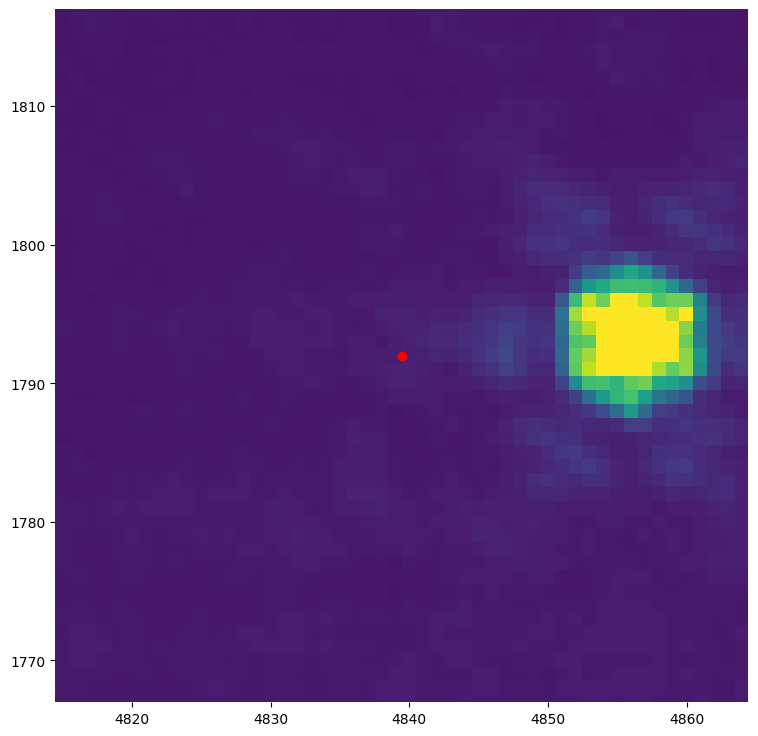

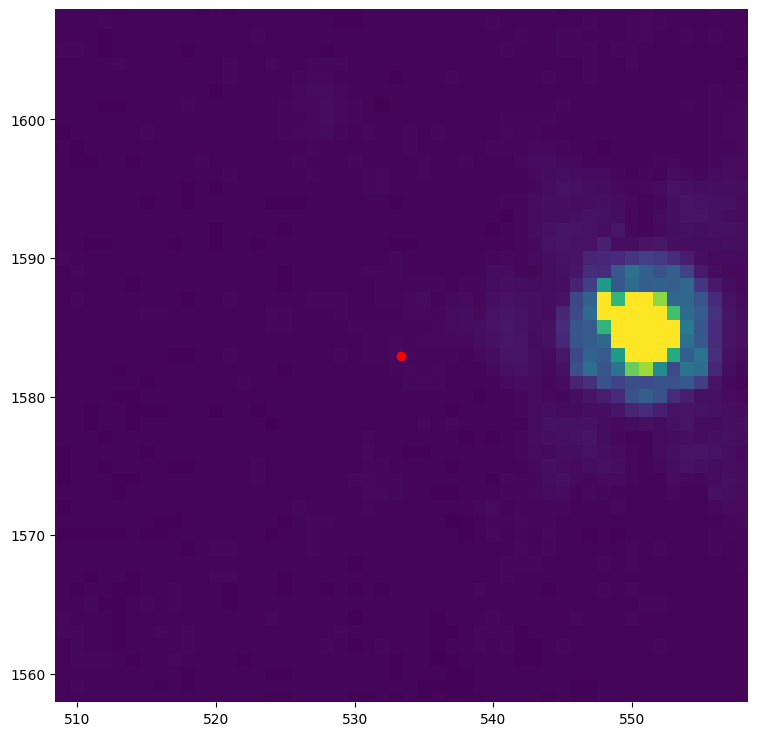

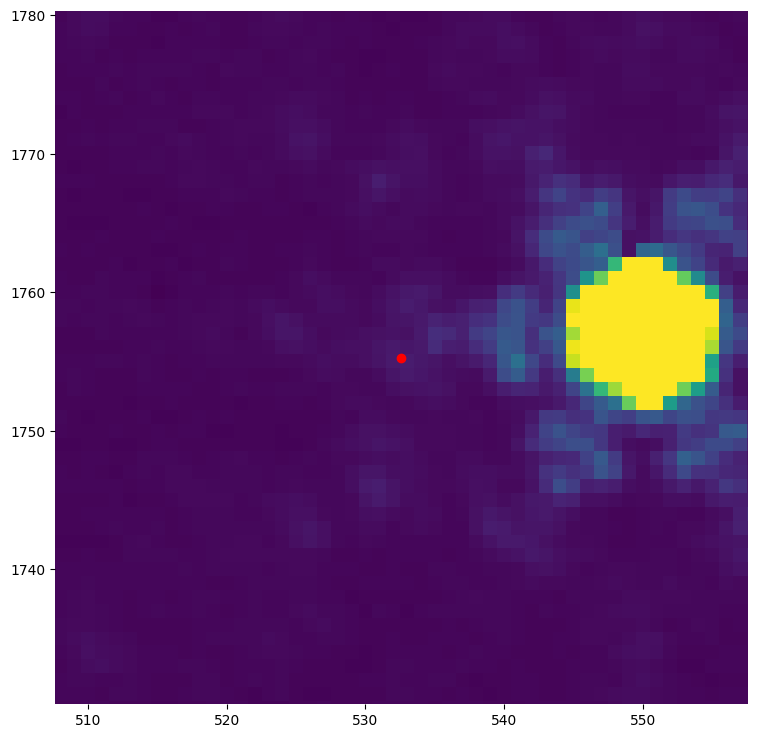

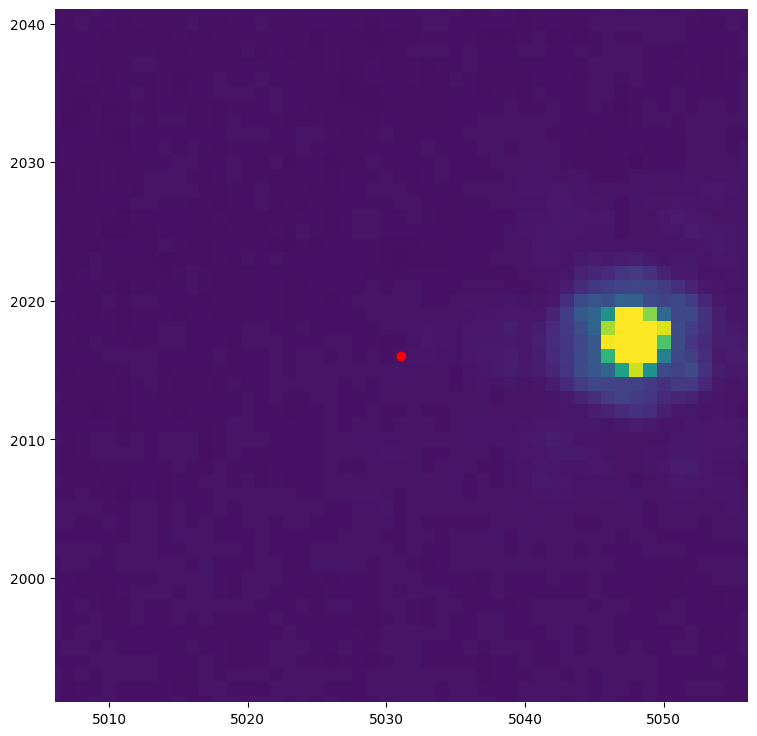

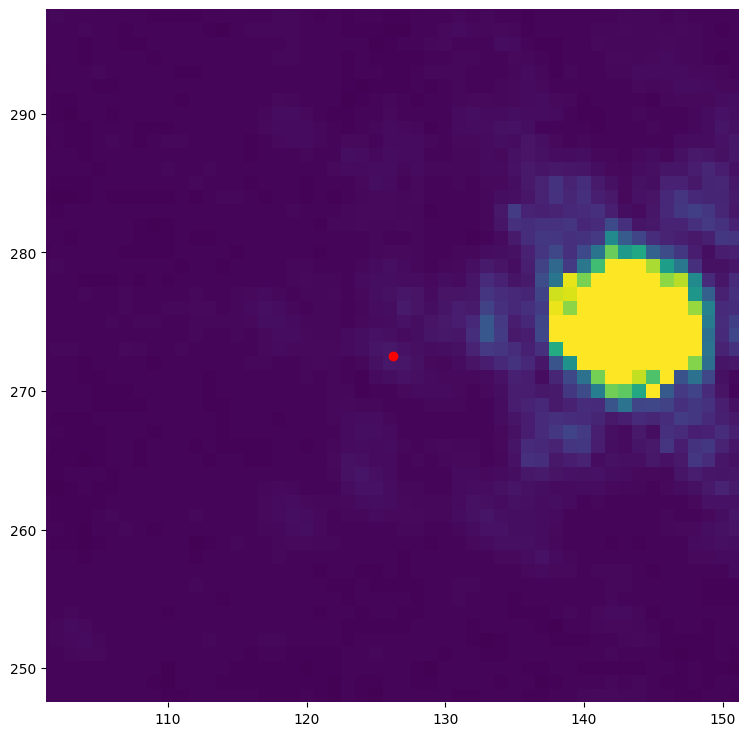

In [5]:
star_check(image, header, gaia_star_field)

100%|██████████| 251001/251001 [00:31<00:00, 8067.06it/s]


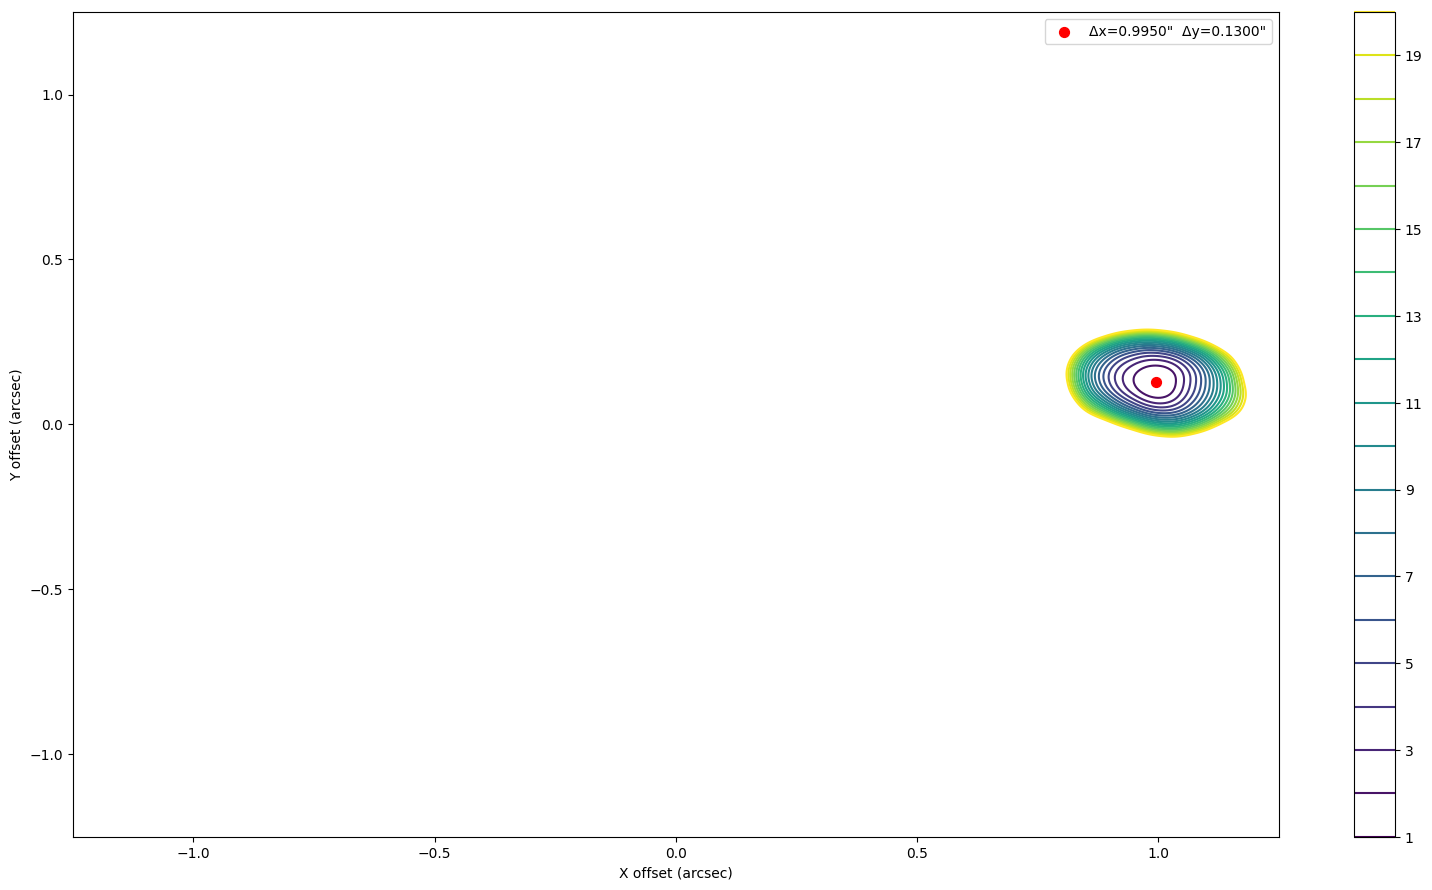

100%|██████████| 251001/251001 [00:30<00:00, 8204.81it/s]


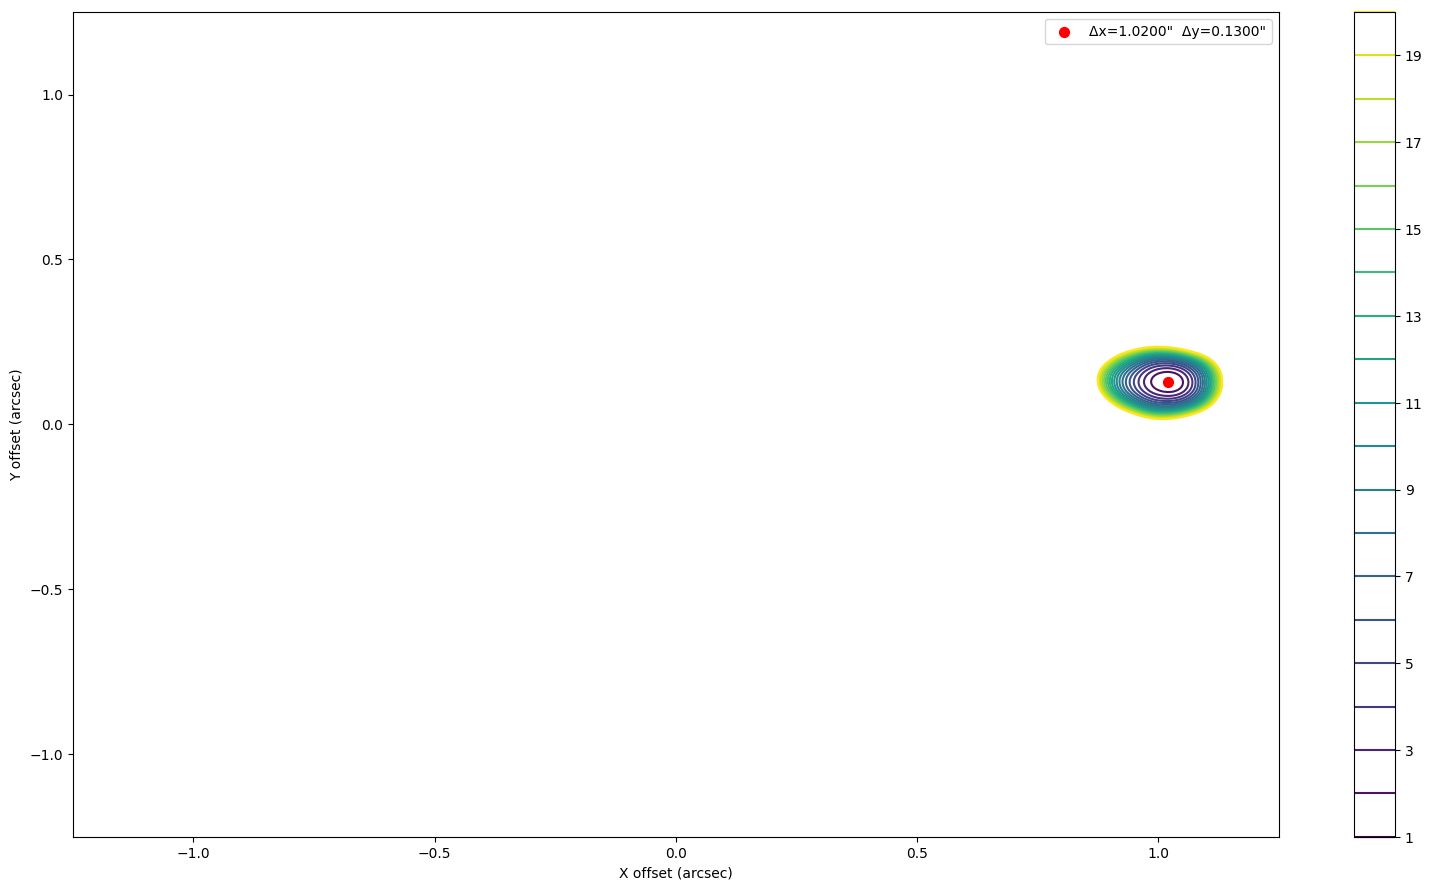

100%|██████████| 251001/251001 [00:31<00:00, 7926.45it/s]


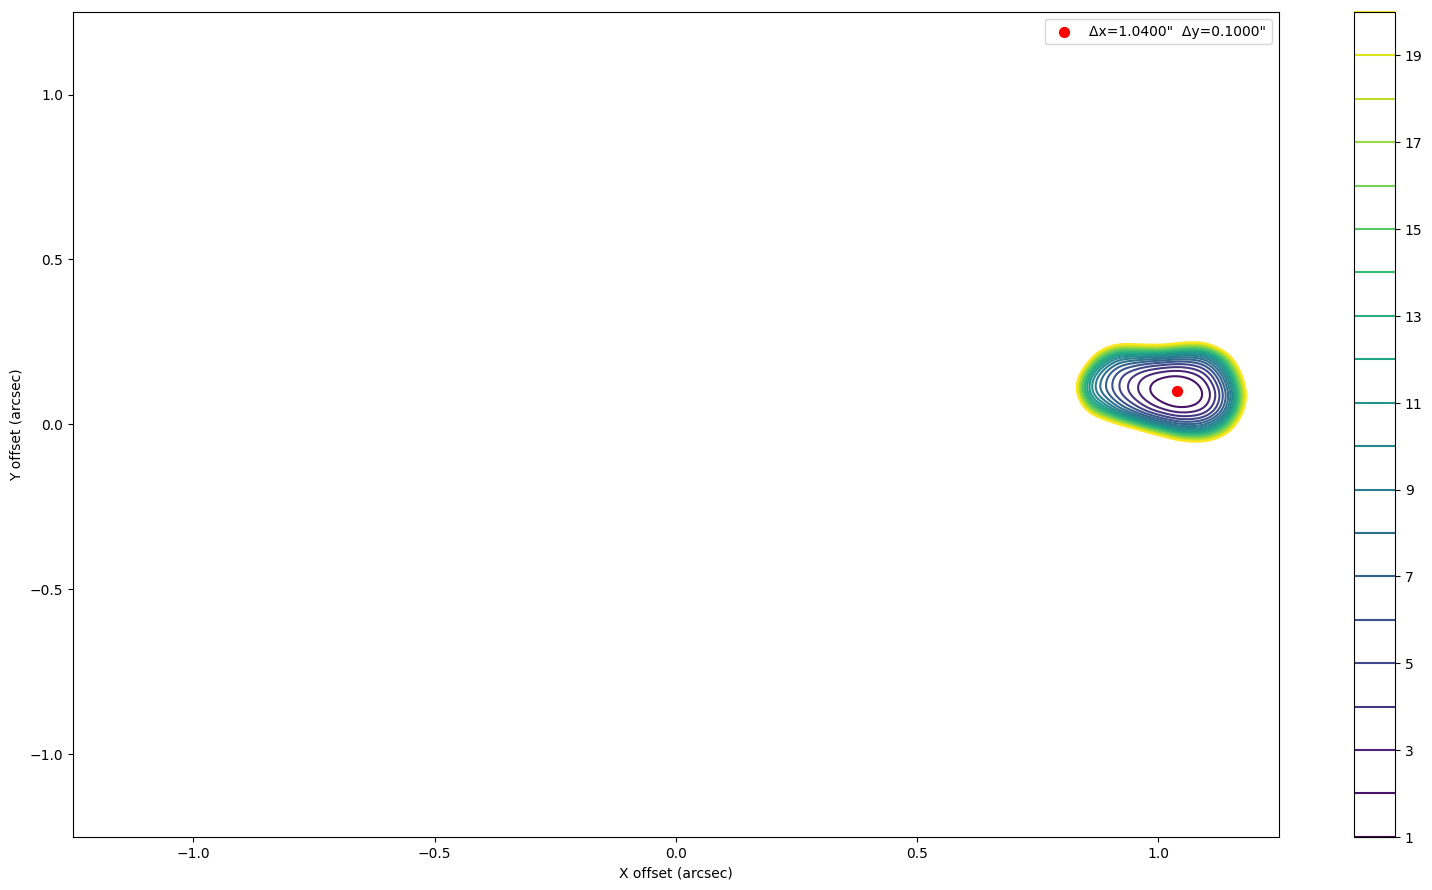

100%|██████████| 251001/251001 [00:31<00:00, 8085.10it/s]


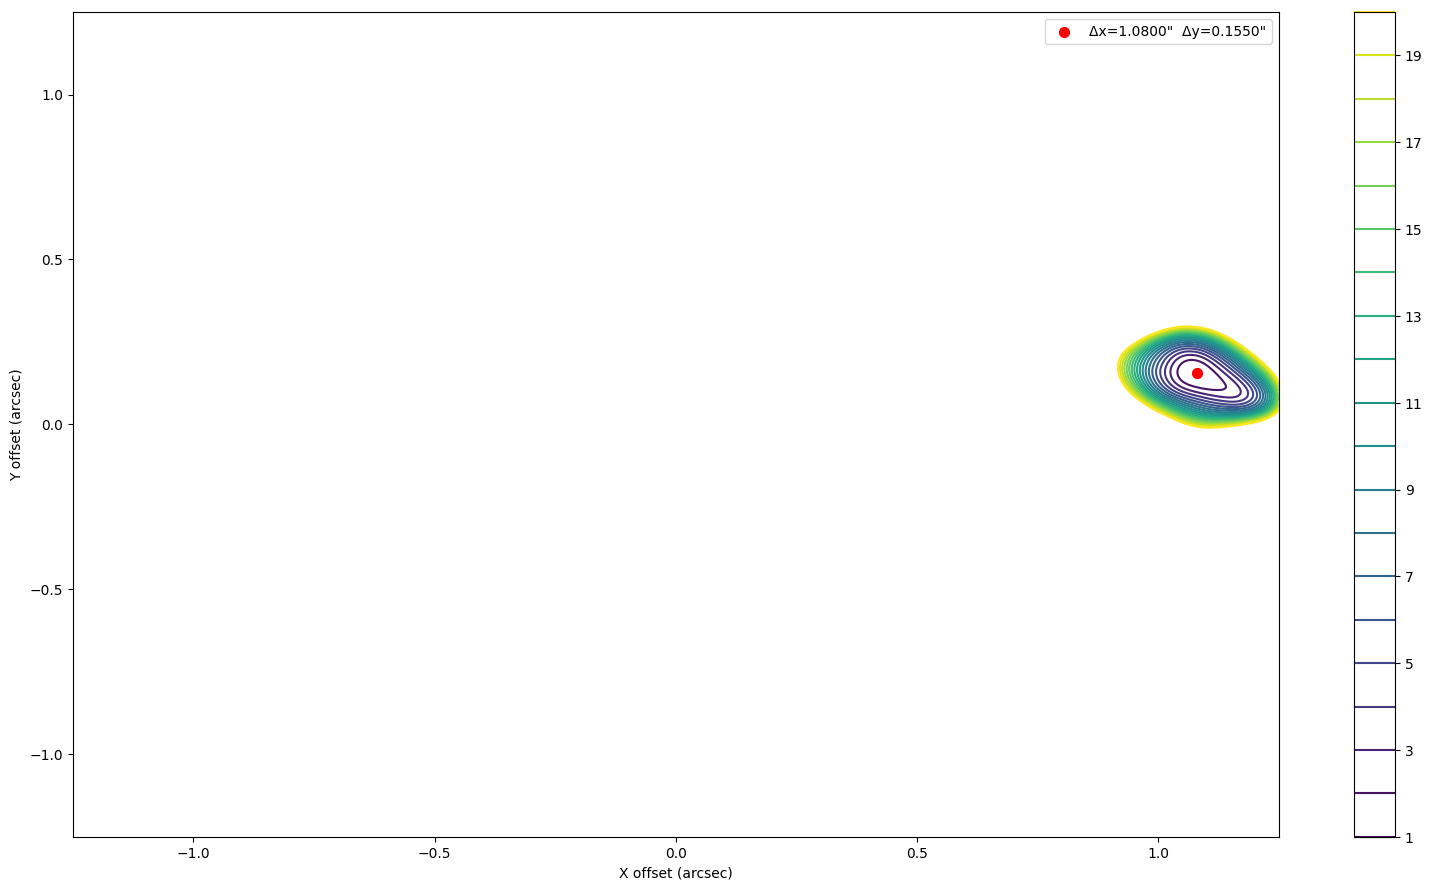

100%|██████████| 251001/251001 [00:30<00:00, 8156.54it/s]


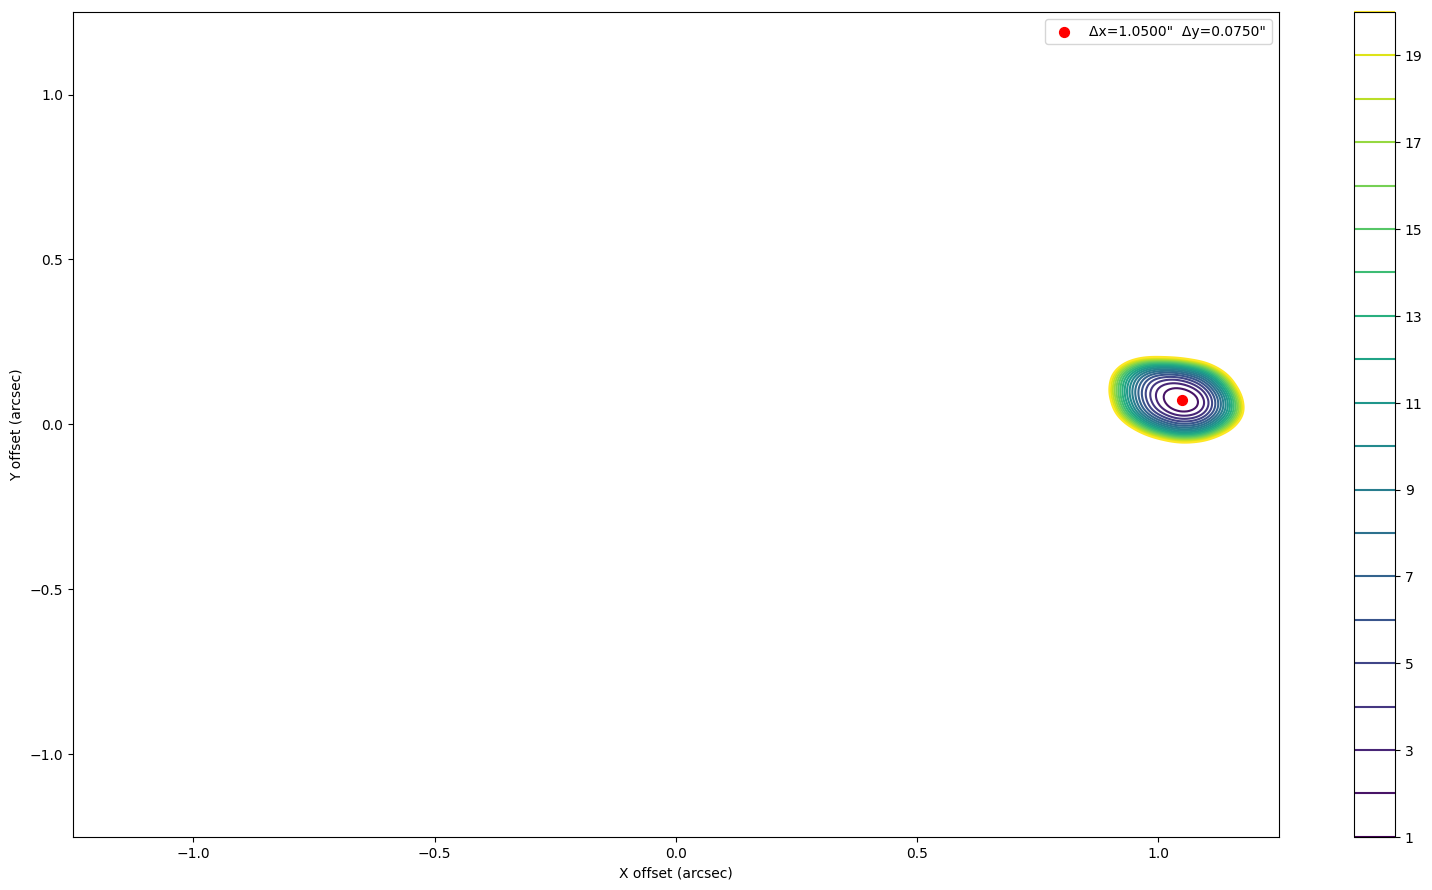

100%|██████████| 251001/251001 [00:30<00:00, 8160.52it/s]


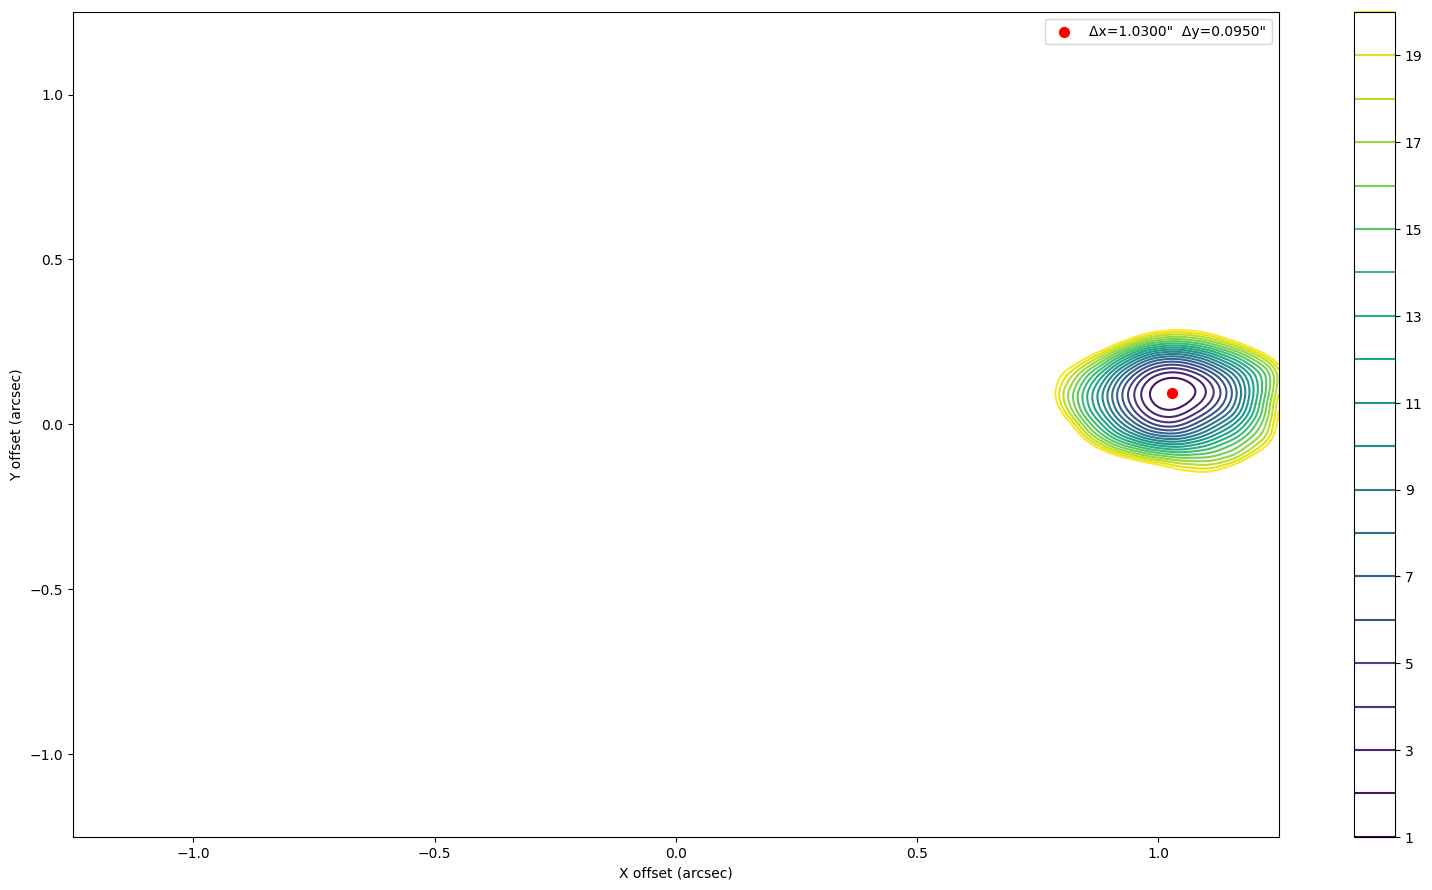

100%|██████████| 251001/251001 [00:30<00:00, 8179.37it/s]


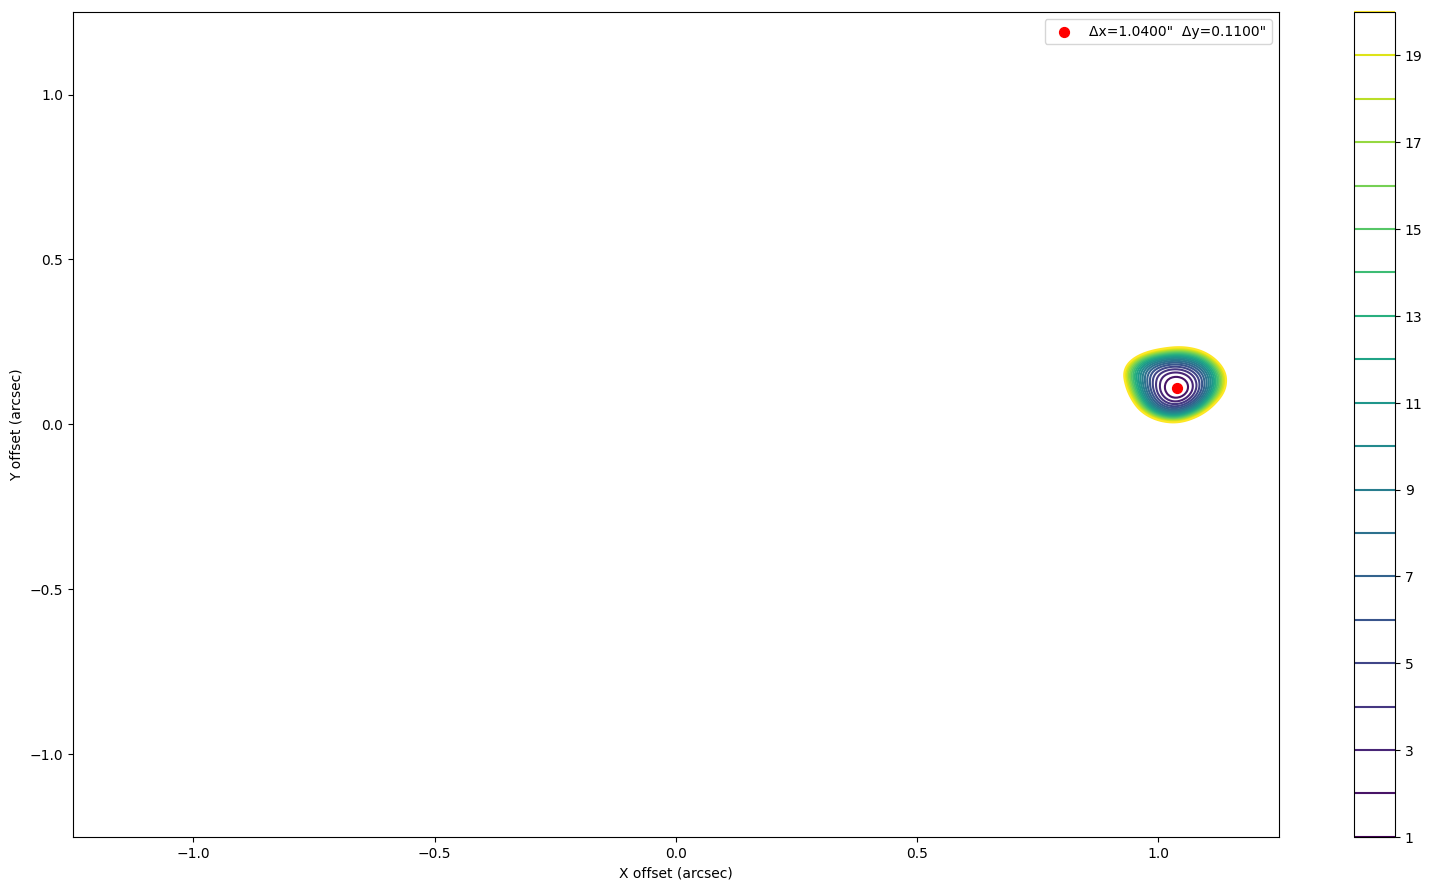

100%|██████████| 251001/251001 [00:30<00:00, 8164.61it/s]


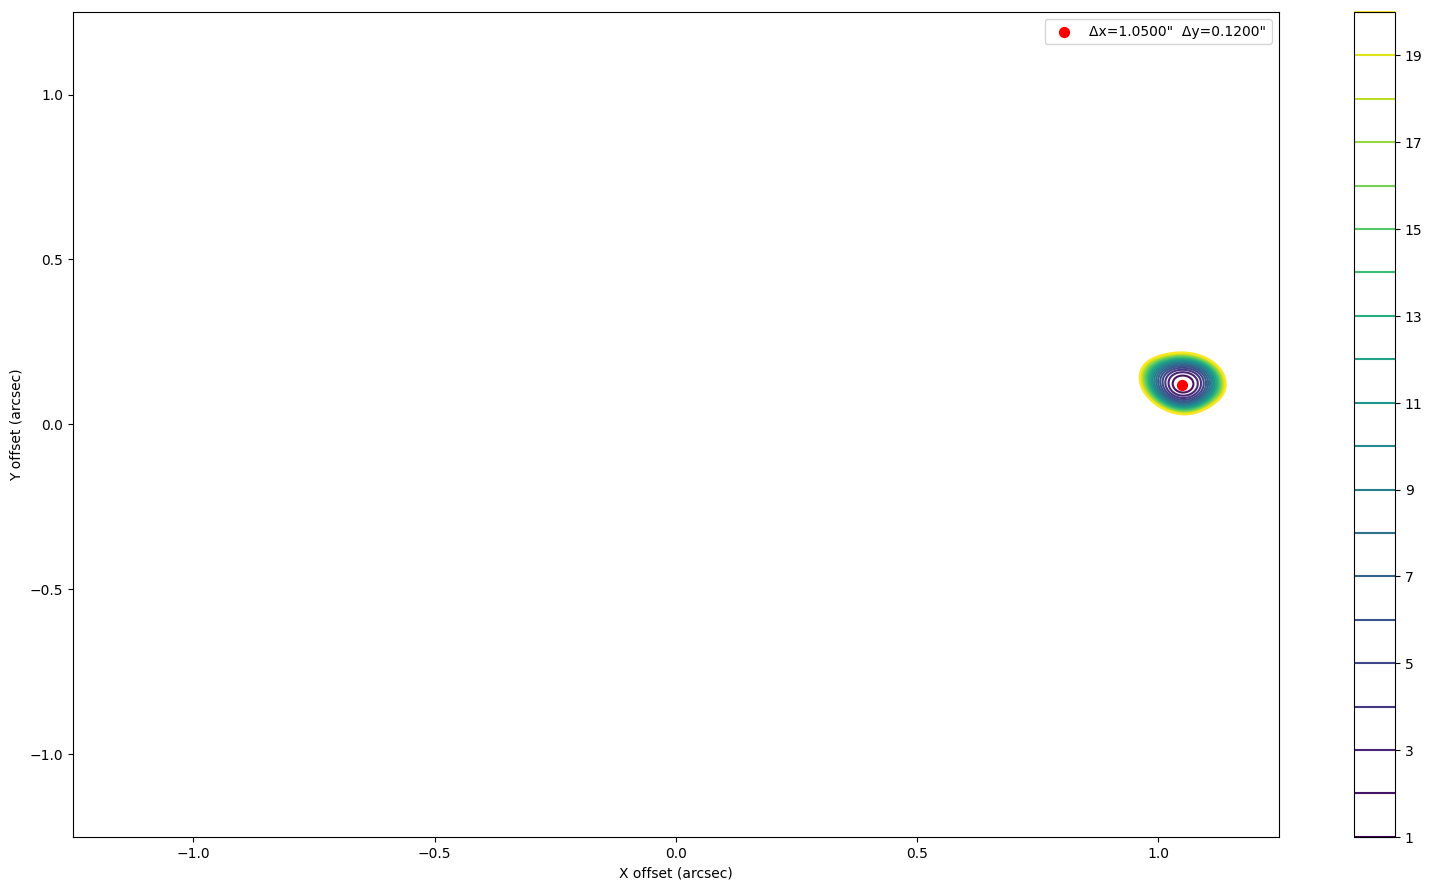

100%|██████████| 251001/251001 [00:30<00:00, 8209.56it/s]


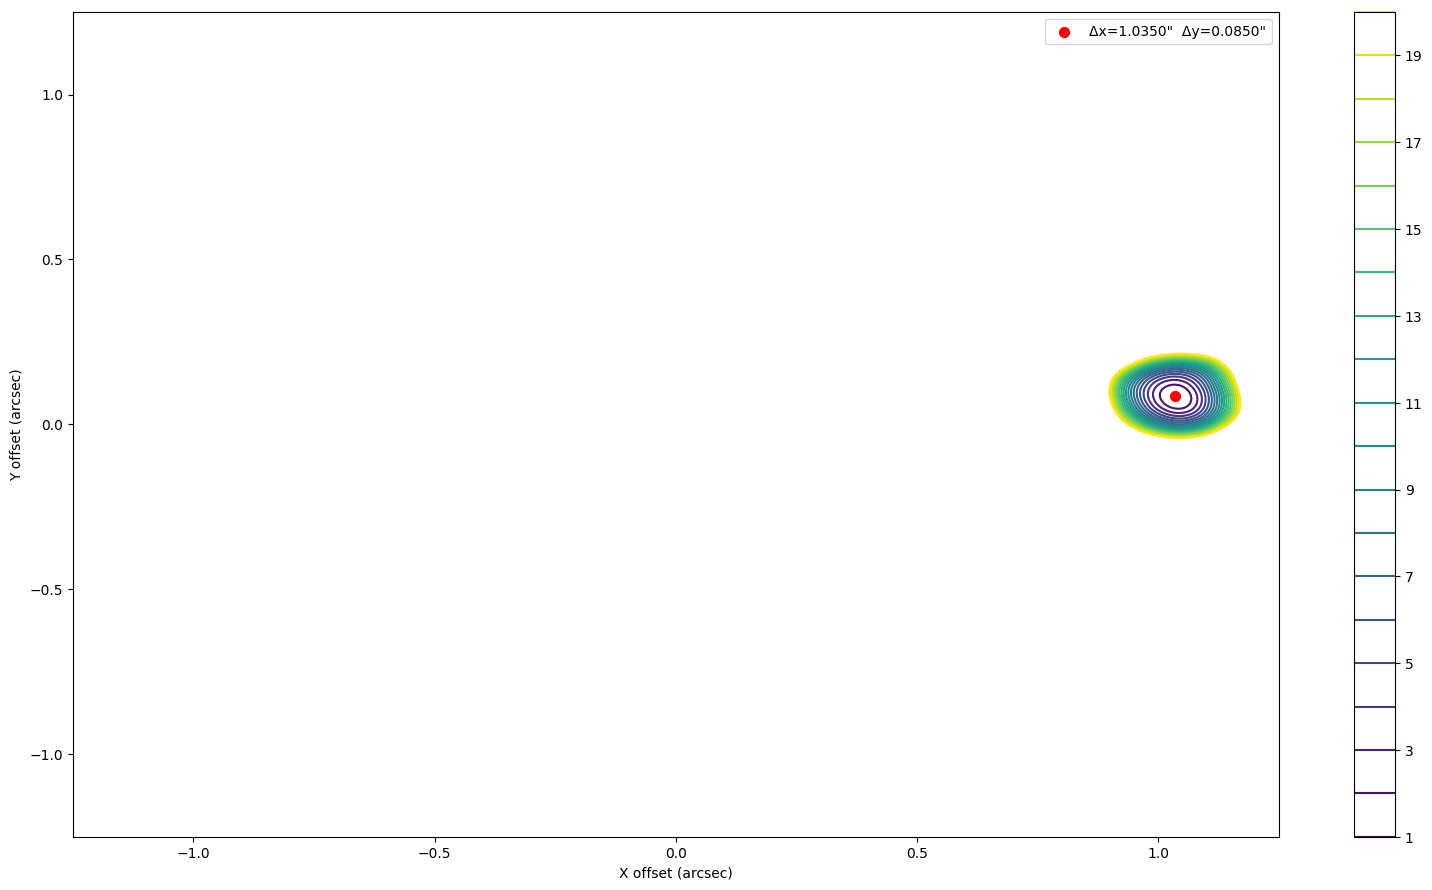

100%|██████████| 251001/251001 [00:30<00:00, 8135.78it/s]


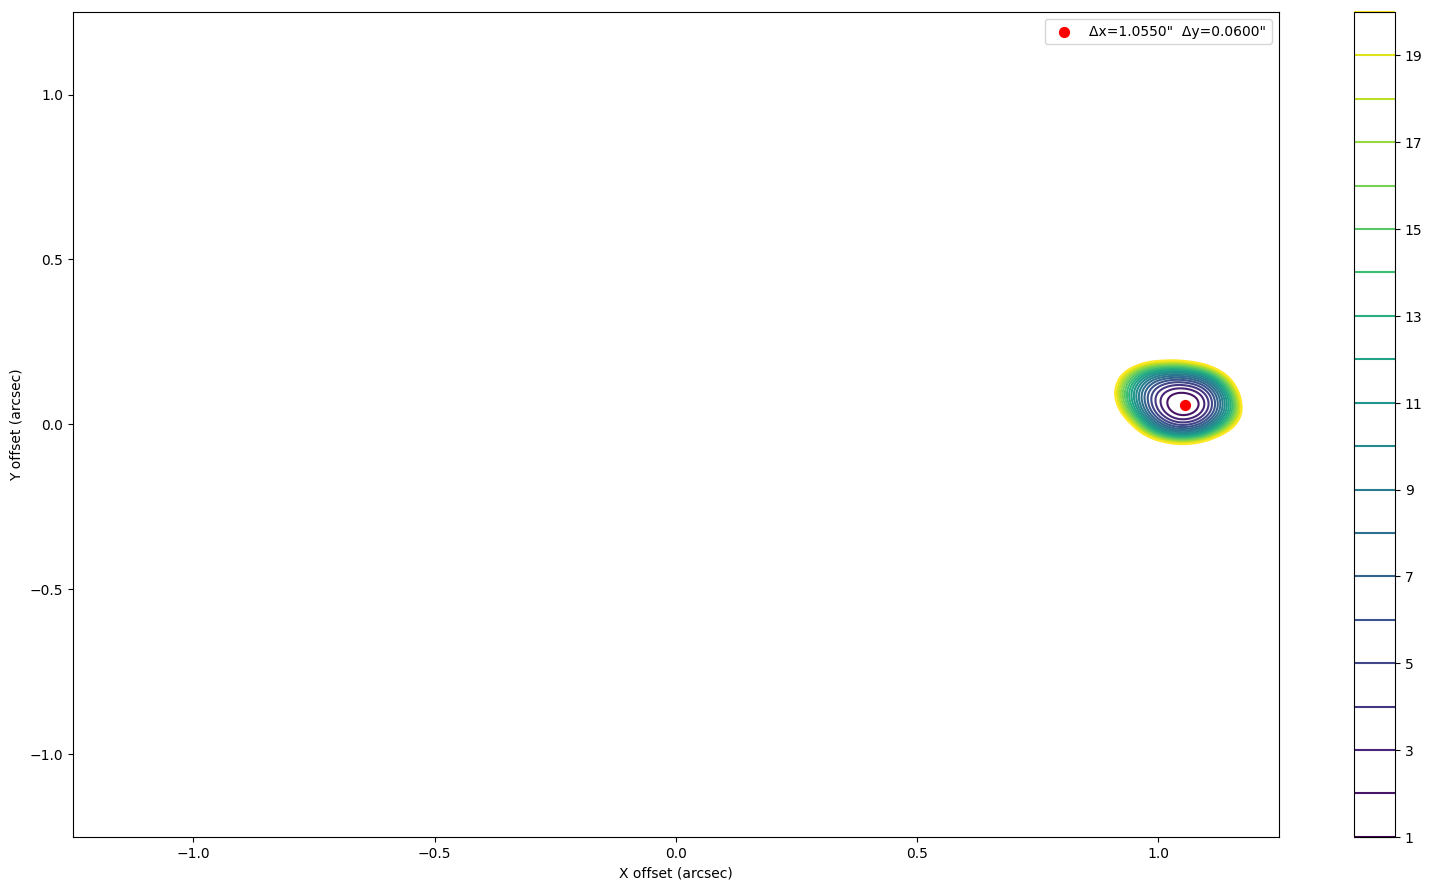

100%|██████████| 251001/251001 [00:30<00:00, 8174.92it/s]


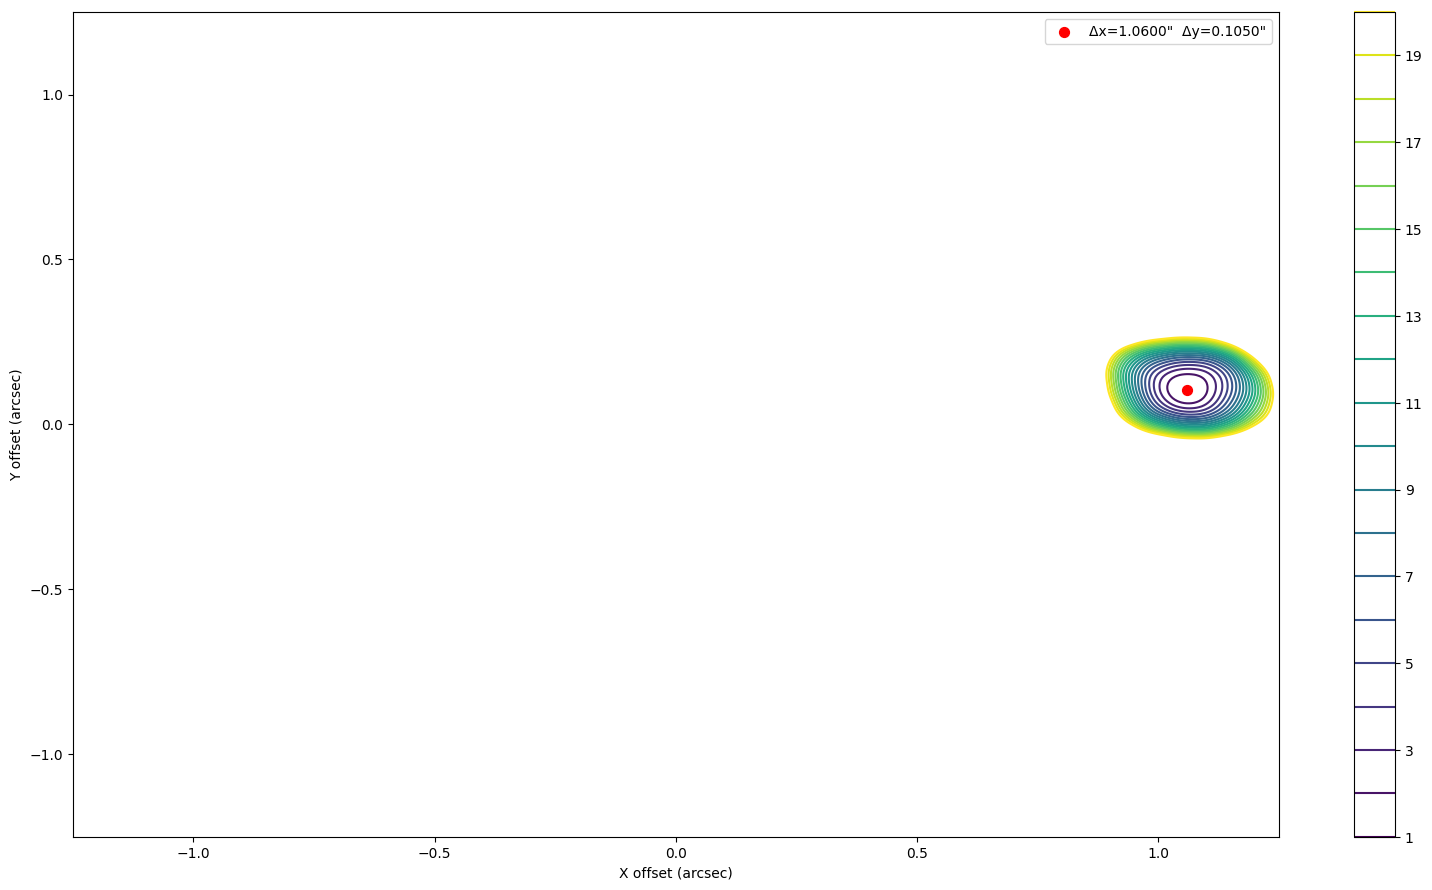

100%|██████████| 251001/251001 [00:31<00:00, 8026.86it/s]


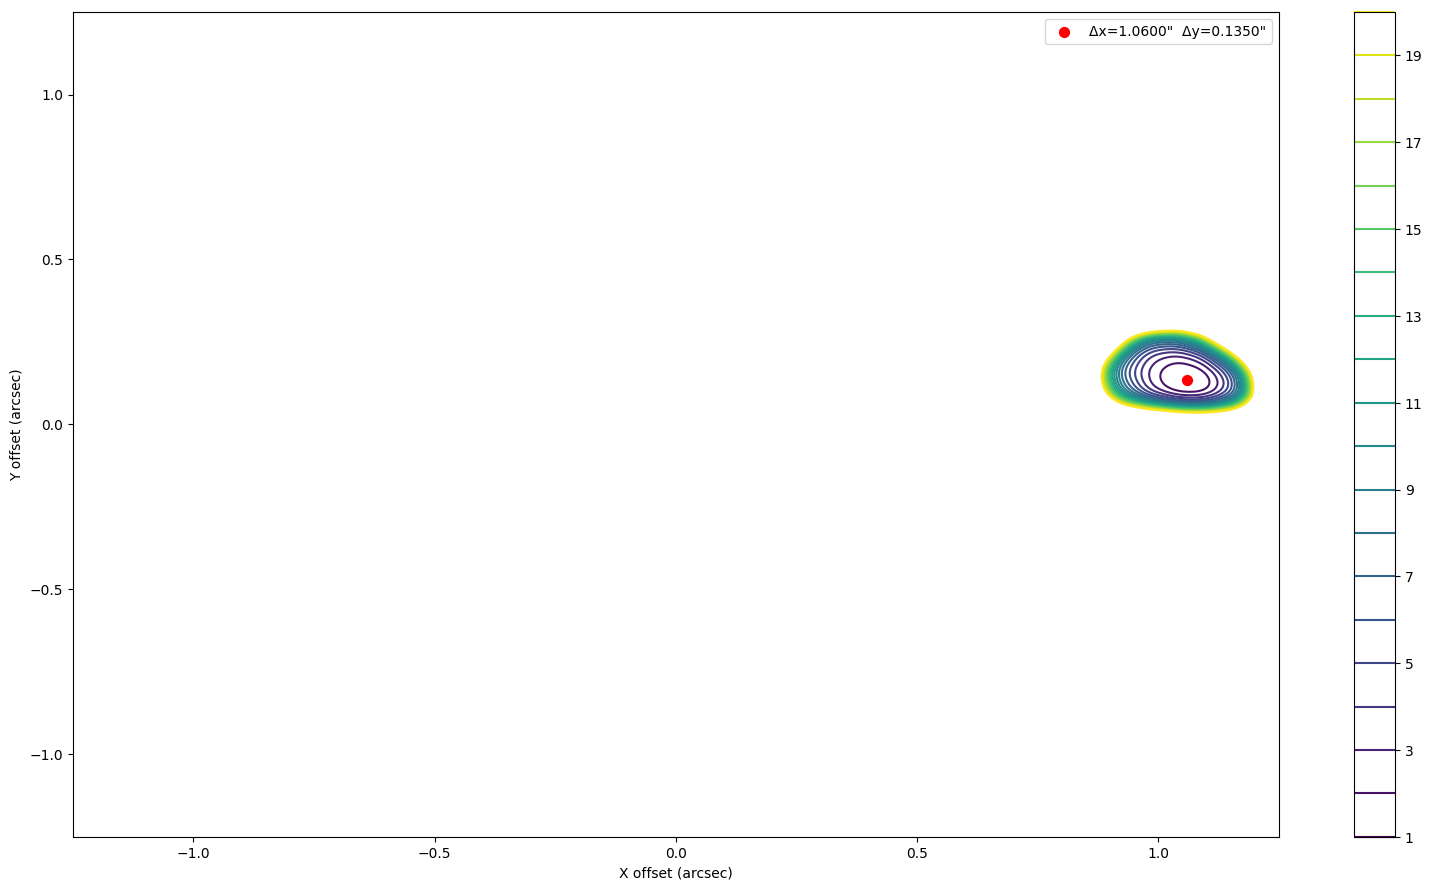

100%|██████████| 251001/251001 [00:31<00:00, 8058.52it/s]


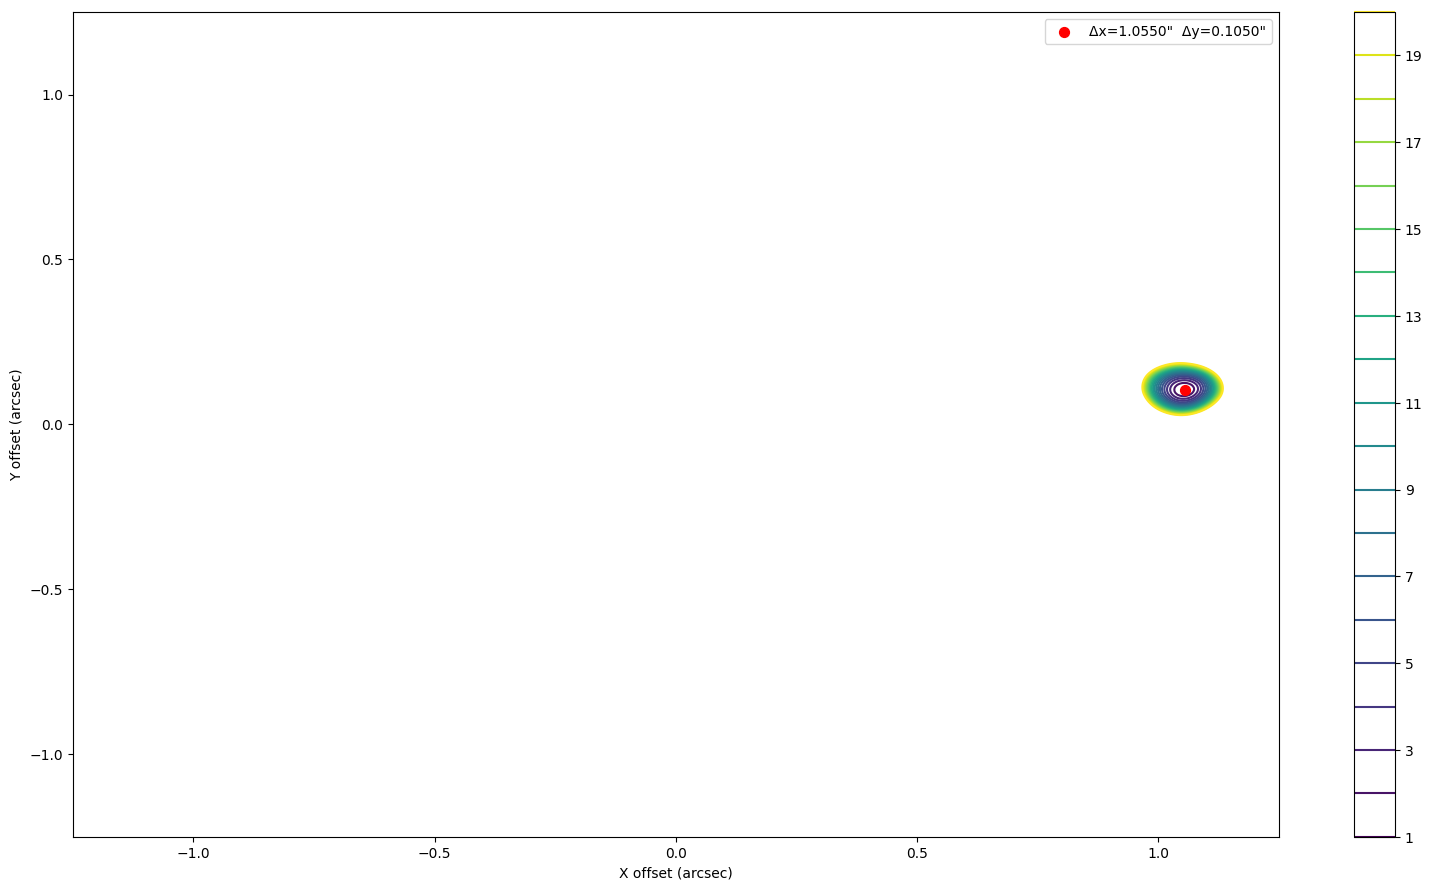

100%|██████████| 251001/251001 [00:30<00:00, 8267.32it/s]


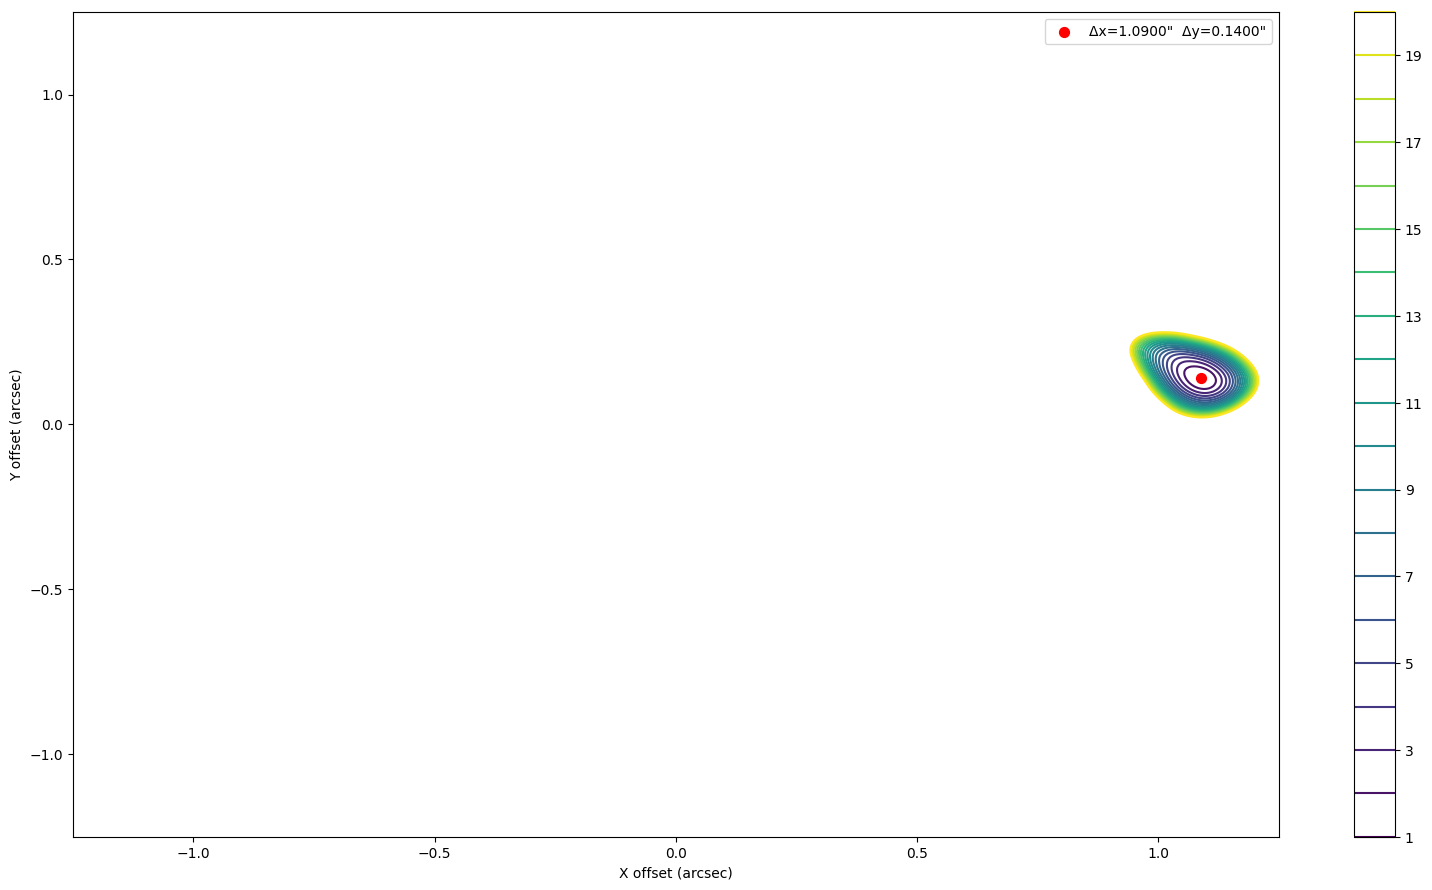

100%|██████████| 251001/251001 [00:31<00:00, 8094.81it/s]


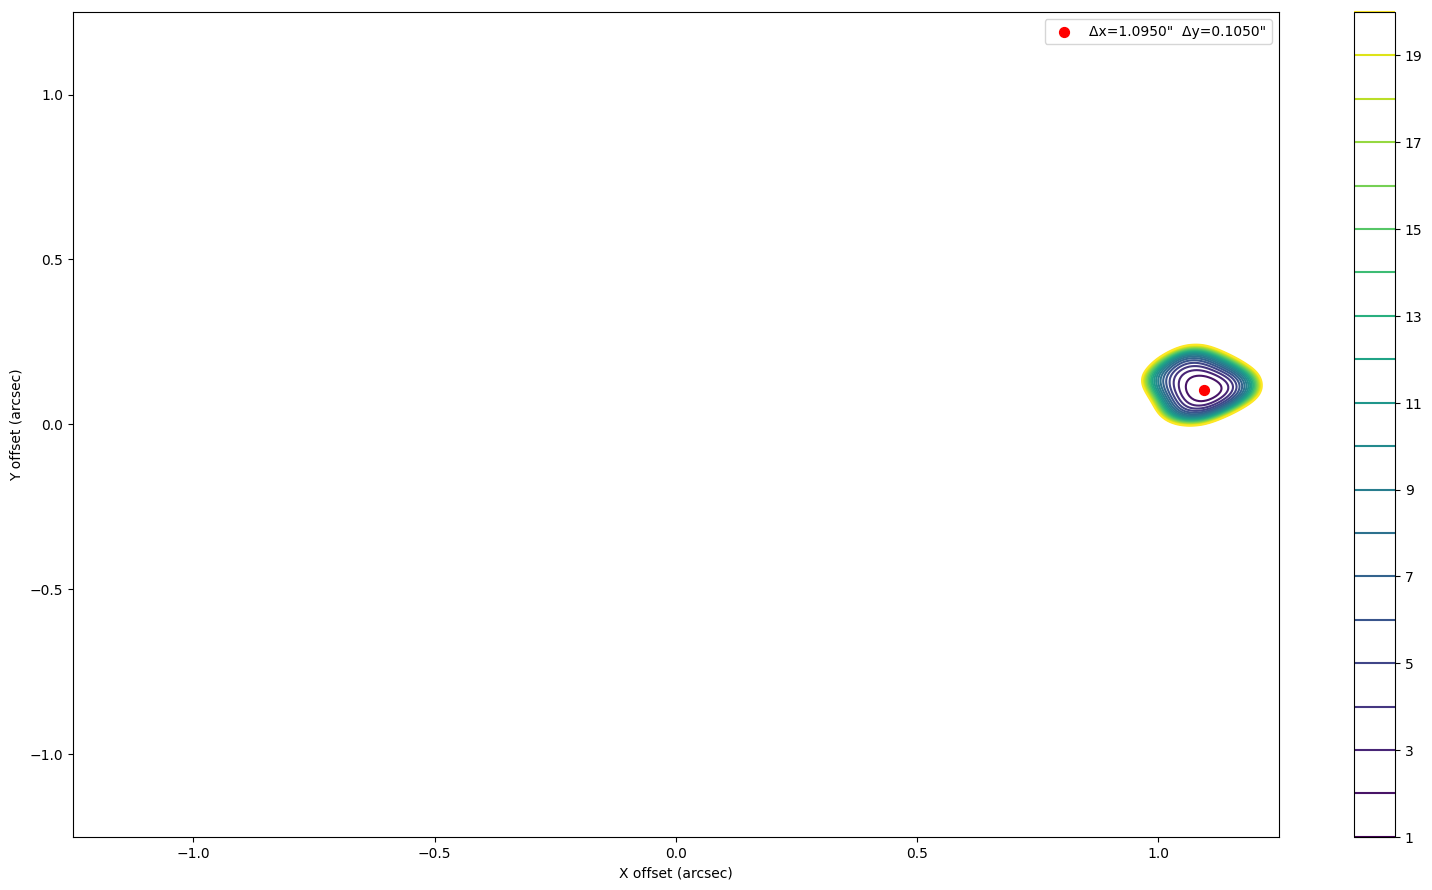

100%|██████████| 251001/251001 [00:30<00:00, 8316.31it/s]


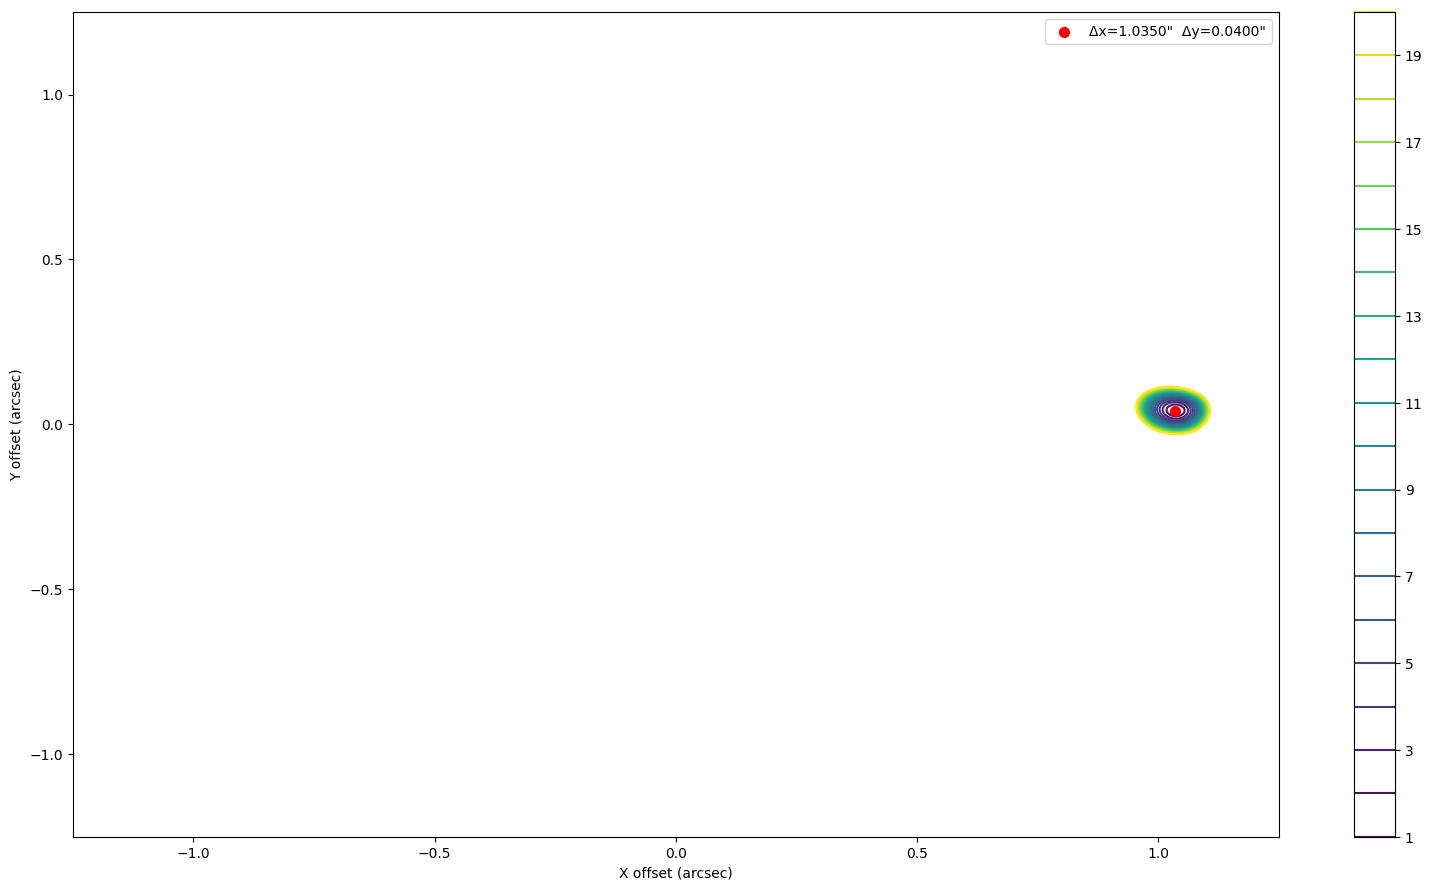

100%|██████████| 251001/251001 [00:30<00:00, 8258.62it/s]


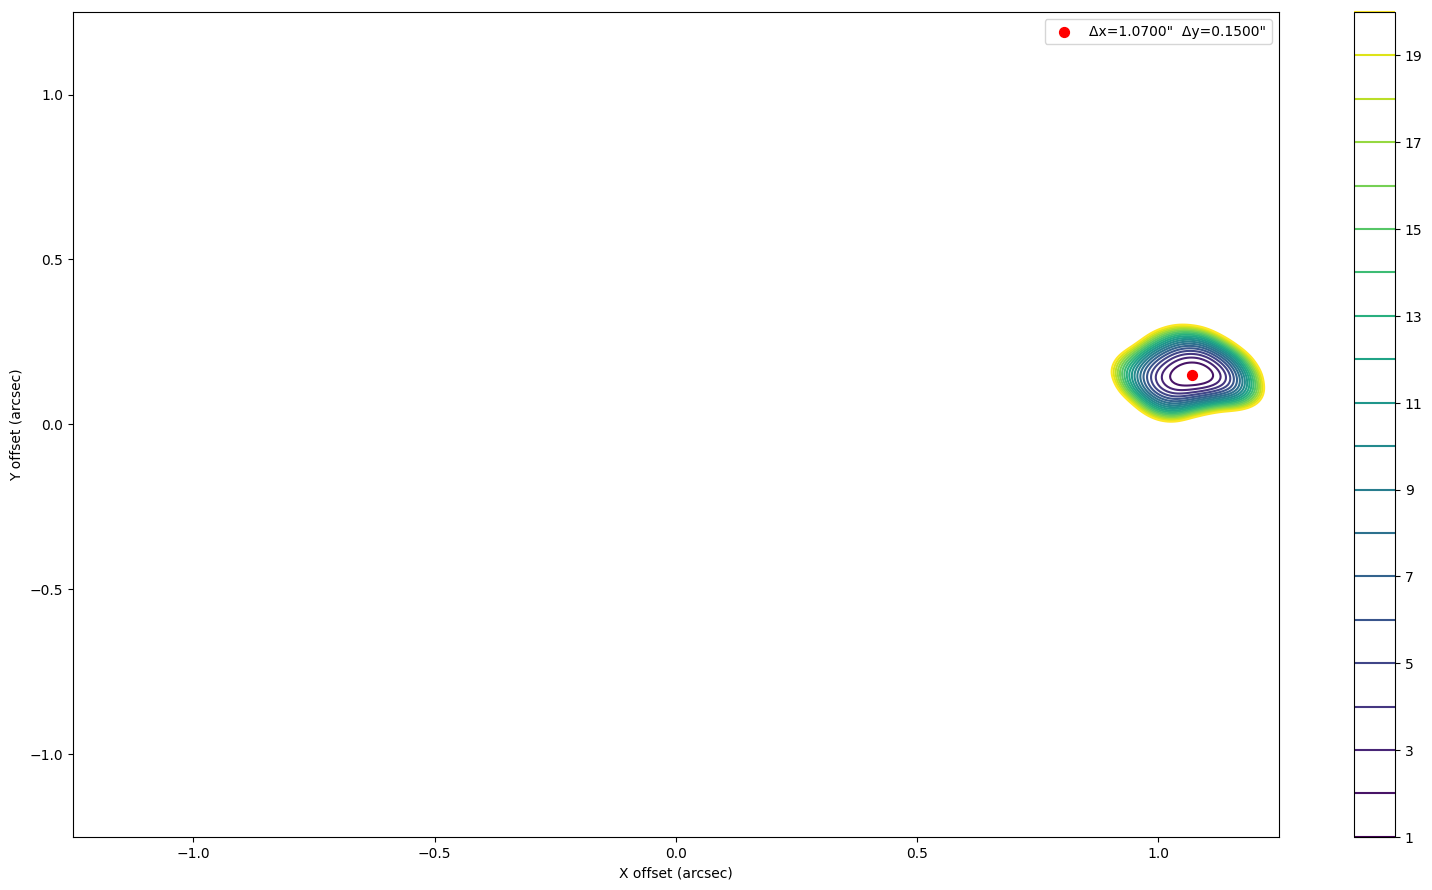

In [6]:
shift_amount = .005 # arcseconds
test_size = 250

min_value = []
best_x = []
best_y = []
area = []
height_error = []
length_error = []
# number = np.zeros(1)
for k in range(len(x_coords)):
    best_idx, best_dx, best_dy, error_area, h_error, w_error = better_psf_fitting(file, header, shift_amount, test_size, gaia_star_field[k])
    min_value.append(best_idx)
    best_x.append(best_dx)
    best_y.append(best_dy)
    area.append(error_area)
    height_error.append(h_error)
    length_error.append(w_error)

In [7]:
print (len(best_y))

best_x = np.array(best_x)
best_y = np.array(best_y)
x_coords = np.array(x_coords)
y_coords = np.array(y_coords)
min_value = np.array(min_value)
area = np.array(area)
height_error = np.array(height_error)
length_error = np.array(length_error)

masked_best_x, masked_best_y, masked_min_value, masked_area, masked_height_error, masked_length_error, masked_x_coords, masked_y_coords = sigma_clip(best_x, best_y, min_value, area, height_error, length_error, x_coords, y_coords, threshold = 2)
print (len(masked_best_y))
masked_best_y, masked_best_x, masked_min_value, masked_area, masked_height_error, masked_length_error, masked_x_coords, masked_y_coords = sigma_clip(masked_best_y, masked_best_x, masked_min_value, masked_area, masked_height_error, masked_length_error, masked_x_coords, masked_y_coords, threshold = 2)
print (len(masked_best_y))

masked_best_x, masked_best_y, masked_min_value, masked_area, masked_height_error, masked_length_error, masked_x_coords, masked_y_coords = sigma_clip(masked_best_x, masked_best_y, masked_min_value, masked_area, masked_height_error, masked_length_error, masked_x_coords, masked_y_coords, threshold = 2)

print (len(masked_best_y))

17
16
15
15


In [8]:
print ((np.std(masked_best_x) / np.sqrt(len(masked_best_x)))*1000)
#filter out "high error" stars  threshold 3 =  6.587867636800245
#filter out "high error" stars  threshold 3 =  7.989004464674499
#threshold 2 = 5.363801857858881
#threshold 3 = 5.924588855271716

5.363801857858881


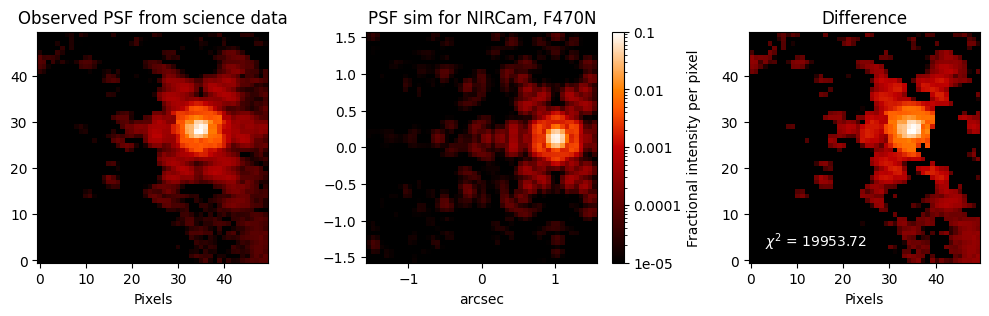

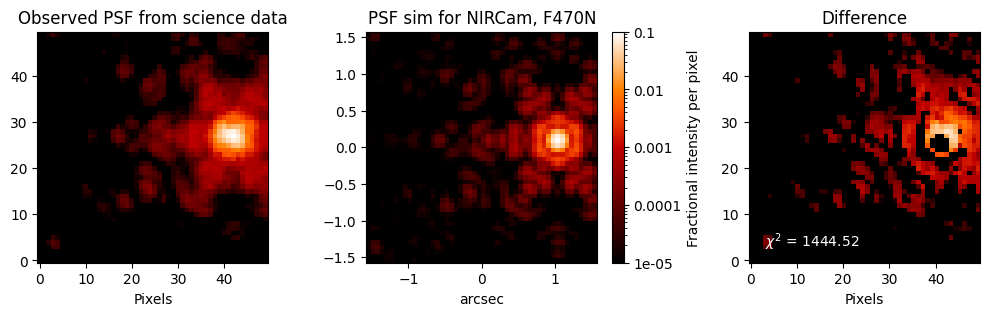

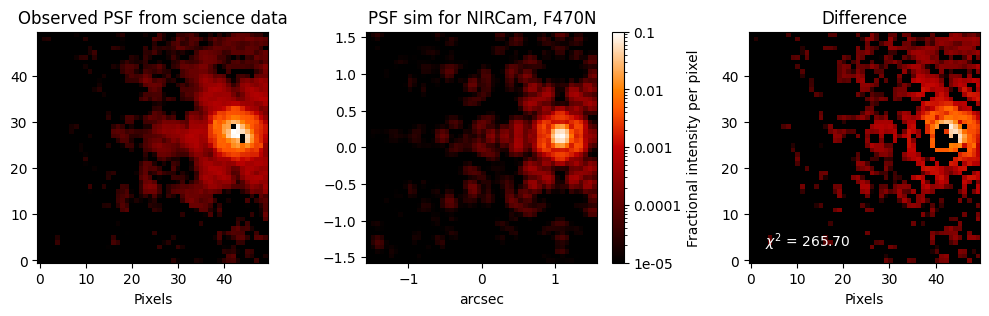

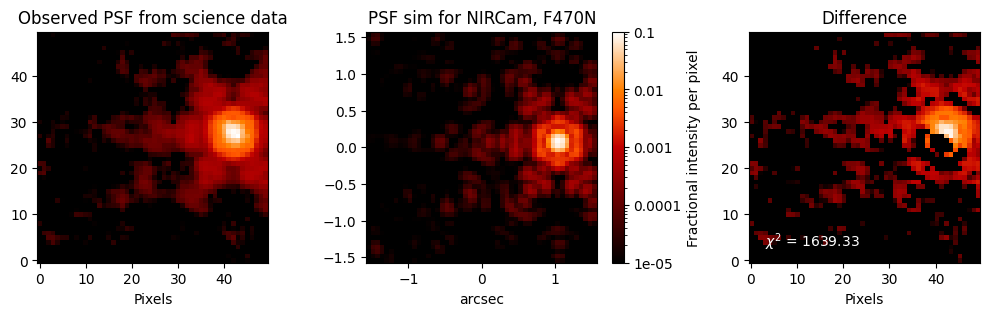

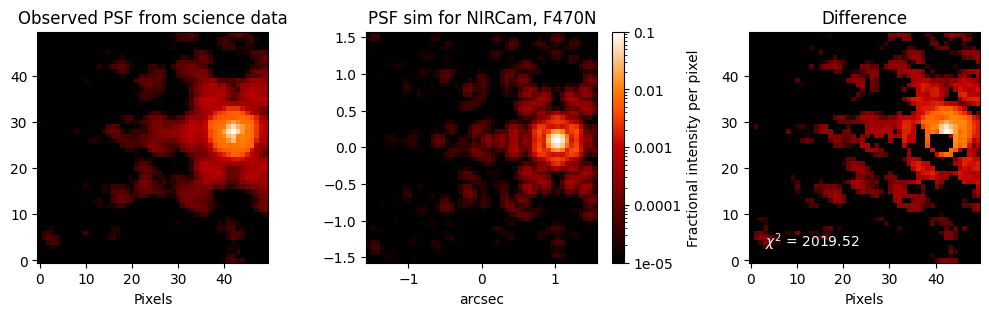

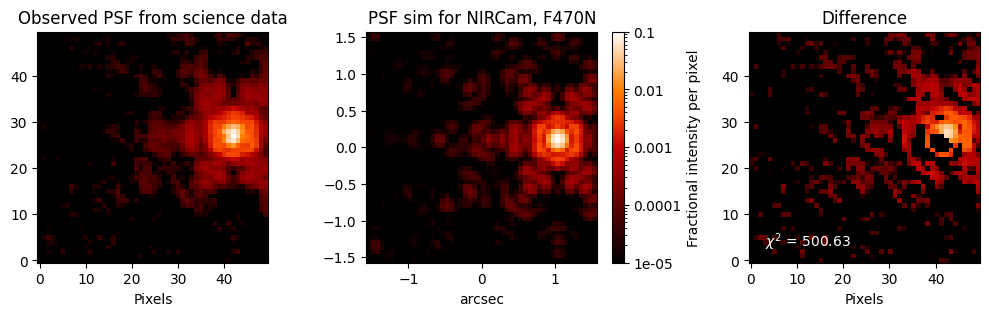

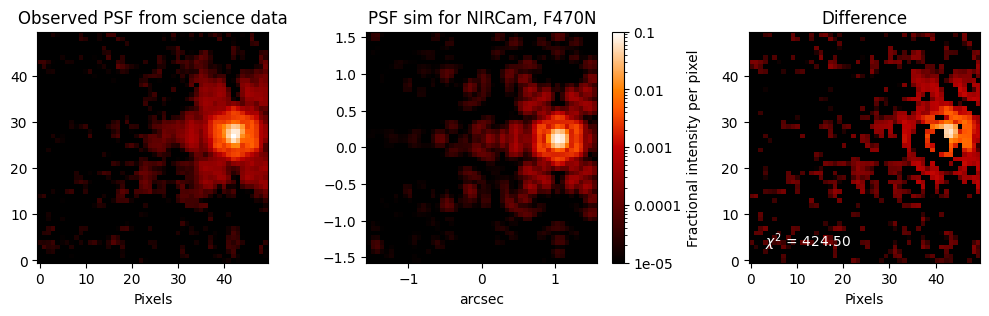

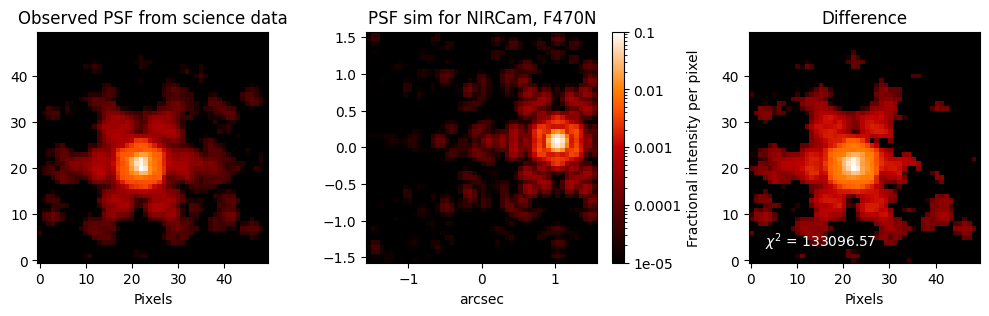

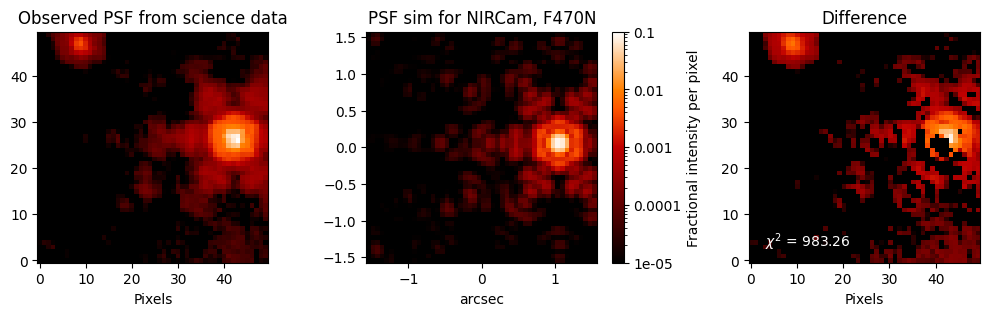

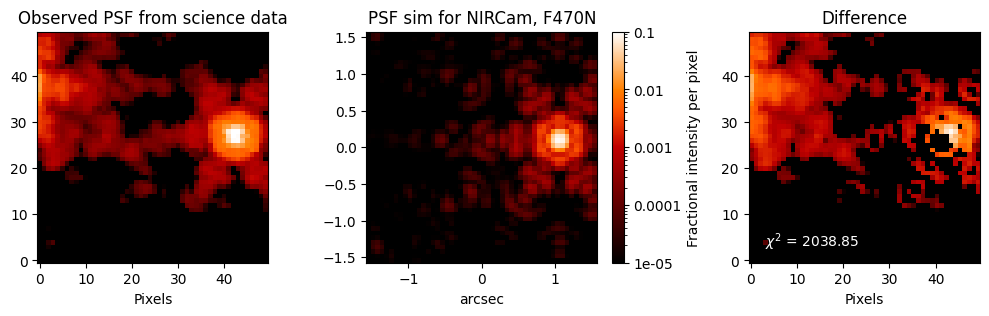

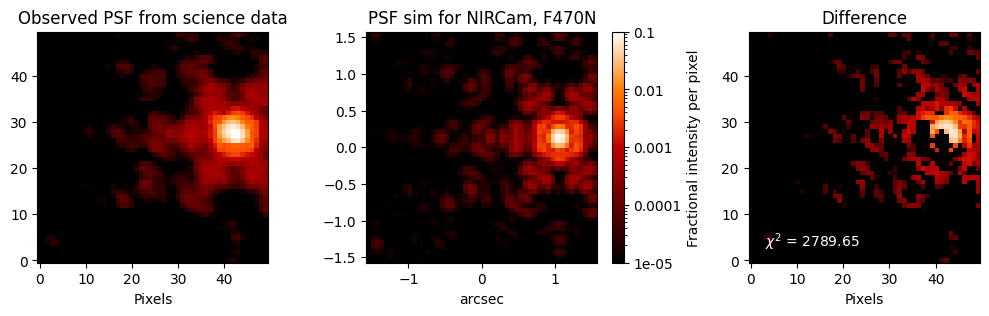

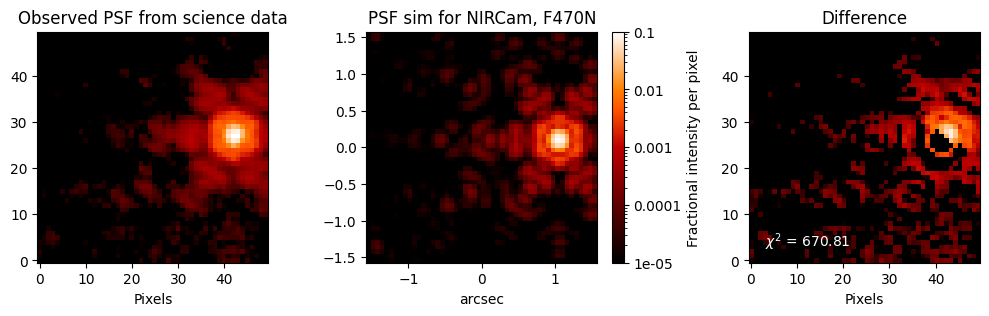

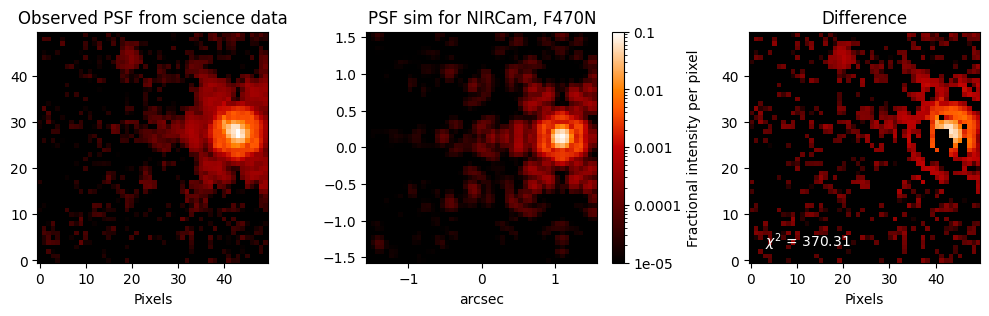

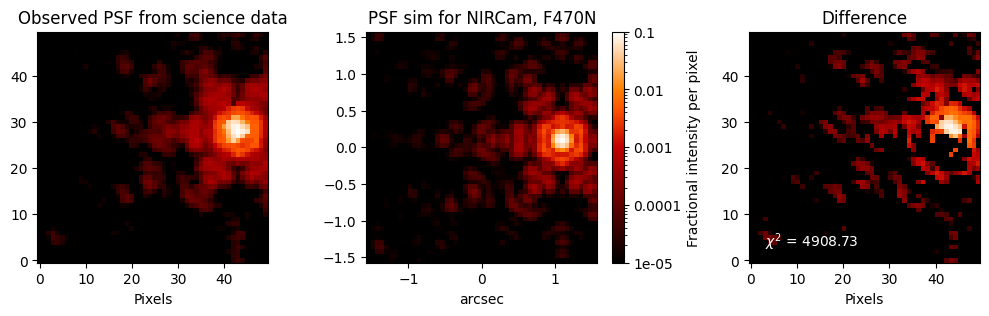

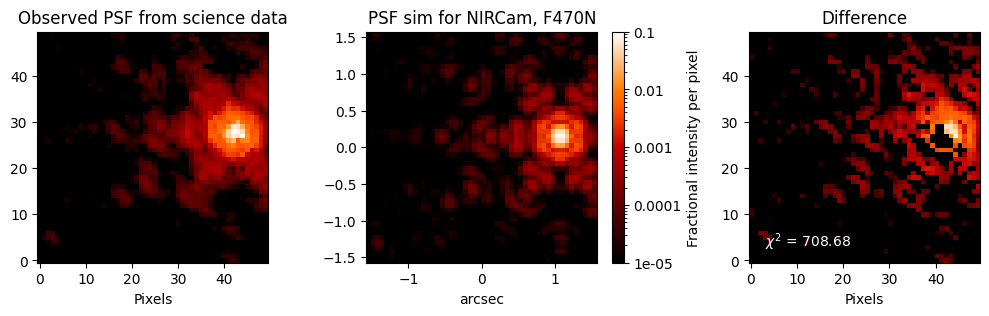

In [9]:
for k in range(len(masked_best_x)):
    psf_center = (masked_x_coords[k], masked_y_coords[k])
    boxsize = 50
    inst = stpsf.setup_sim_to_match_file(file, verbose= False)

    # Load that science data. Cut out the surface brightness and uncertainty for the desired location
    obs_im = fits.open(file)

    obs_psf = Cutout2D(obs_im['SCI'].data, position=psf_center, size=boxsize).data
    obs_psf_err = Cutout2D(obs_im['ERR'].data, position=psf_center, size=boxsize).data

    obs_psf -= np.nanmedian(obs_psf)    # perform a simple background subtraction) 

    inst.options['source_offset_x'] = masked_best_x[k]   # in units of arcseconds. So, this is about 1/5 of a NRC LW pixel
    inst.options['source_offset_y'] = masked_best_y[k]
    sim_psf_offset = inst.calc_psf(fov_pixels=boxsize)

    plot_data_sim_comparison(obs_psf, obs_psf_err, sim_psf_offset)

In [10]:
x_shift = np.mean(masked_best_x)
y_shift = np.mean(masked_best_y)
x_shift_pixel = x_shift / (header['CDELT1']*3600) 
y_shift_pixel = y_shift / (header['CDELT2']*3600)
print (x_shift_pixel, y_shift_pixel)
header['CRPIX1'] += x_shift_pixel
header['CRPIX2'] += y_shift_pixel

16.7690970730803 1.7690708851575552


In [11]:
hdu.writeto(path_image +'gaia-centered-jwst-2026-f444w-f470n.fits', overwrite=True)

In [12]:
hdu = fits.open((path_image + 'gaia-centered-jwst-2026-f444w-f470n.fits'))

INFO: Query finished. [astroquery.utils.tap.core]


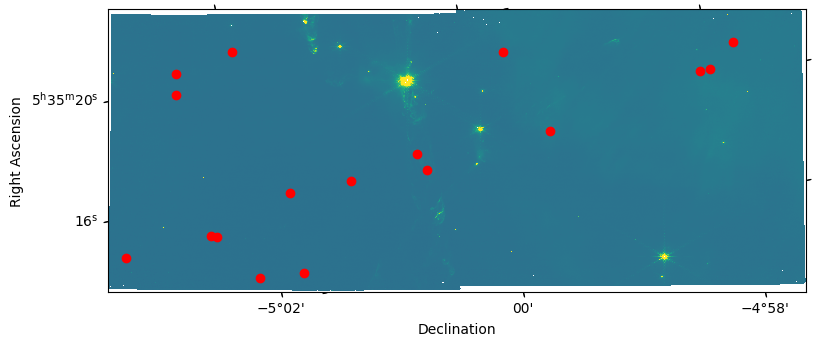

In [13]:
ra_center = hdu[1].header['CRVAL1']
dec_center = hdu[1].header['CRVAL2']
size_deg = .1
image = hdu[1].data
header = hdu[1].header

x_coords, y_coords, l = find_stars(ra_center, dec_center, size_deg, image, header)

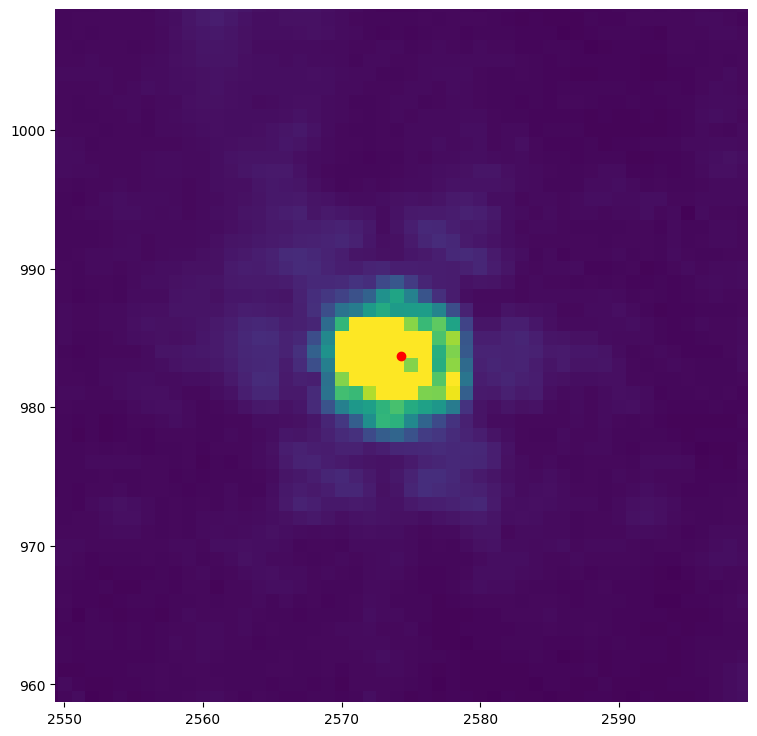

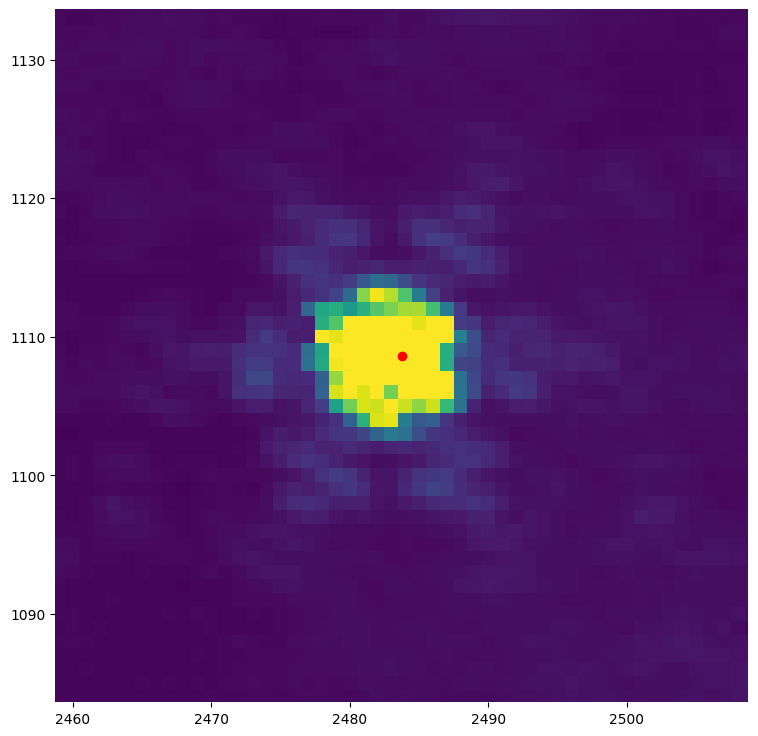

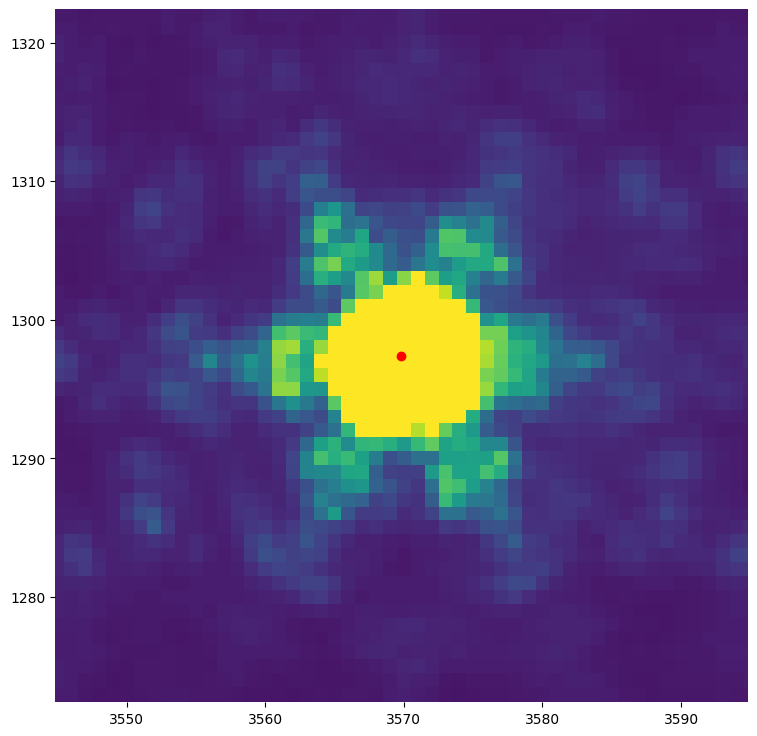

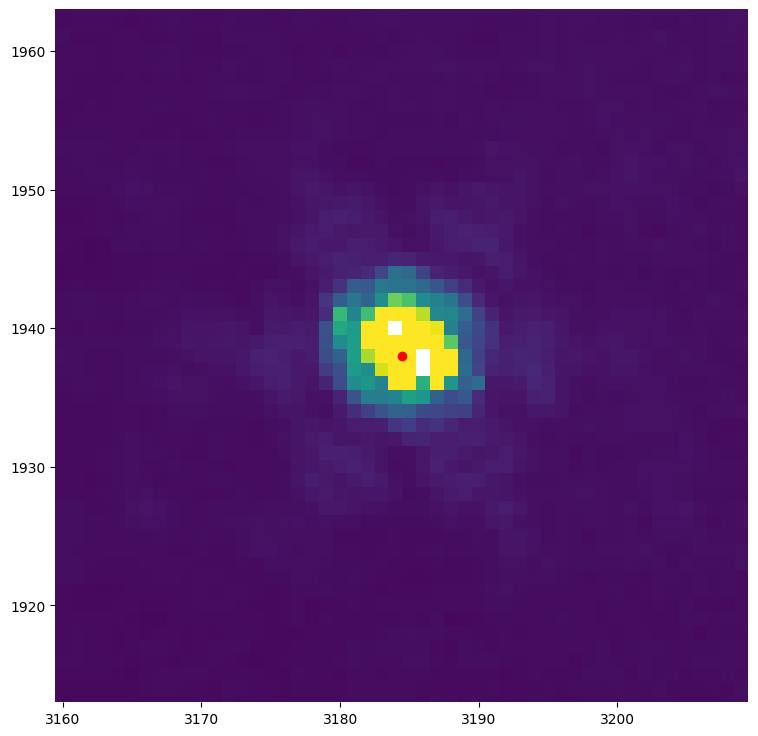

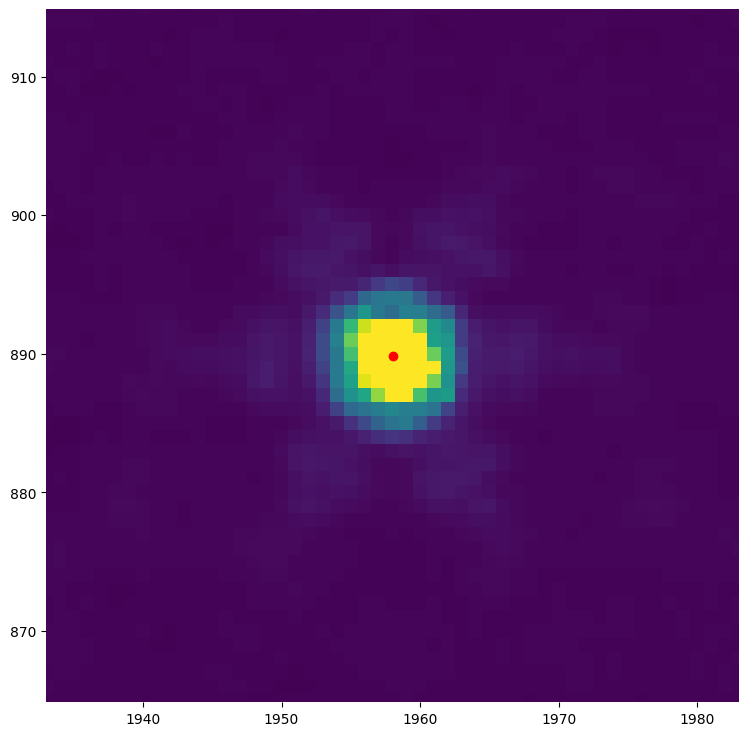

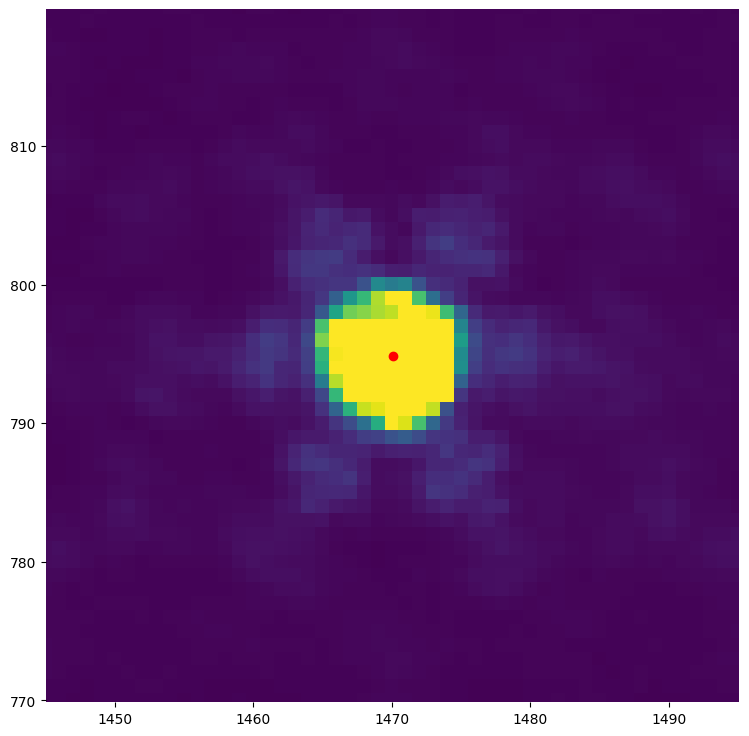

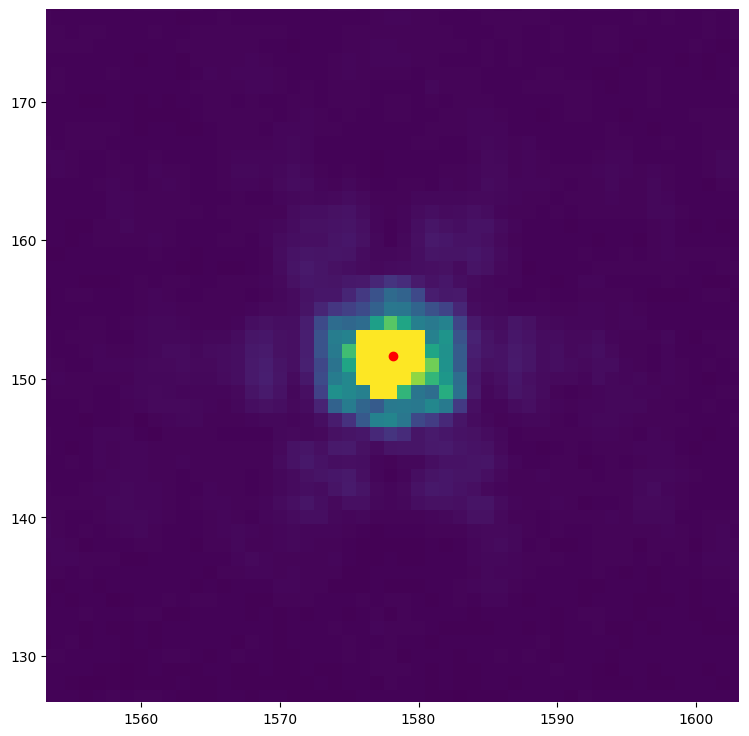

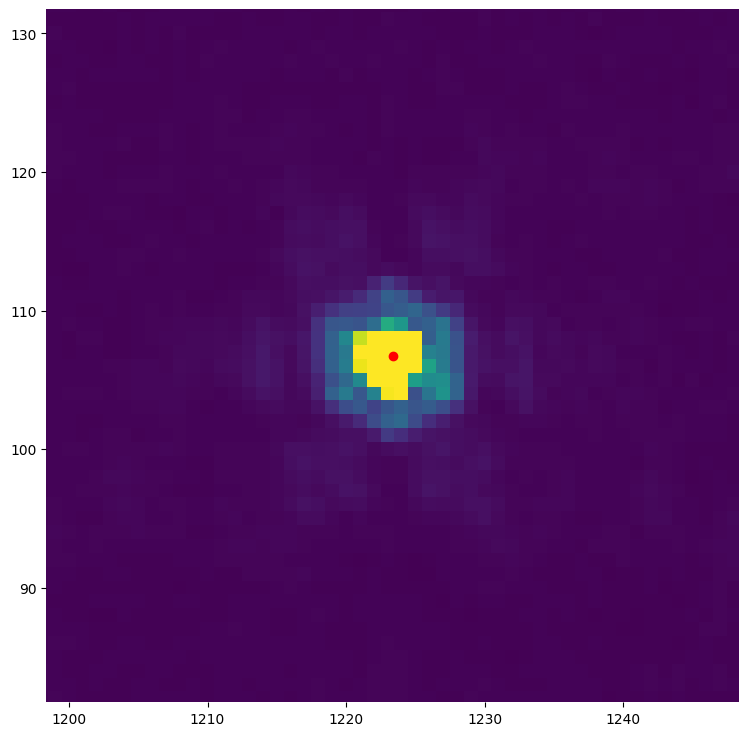

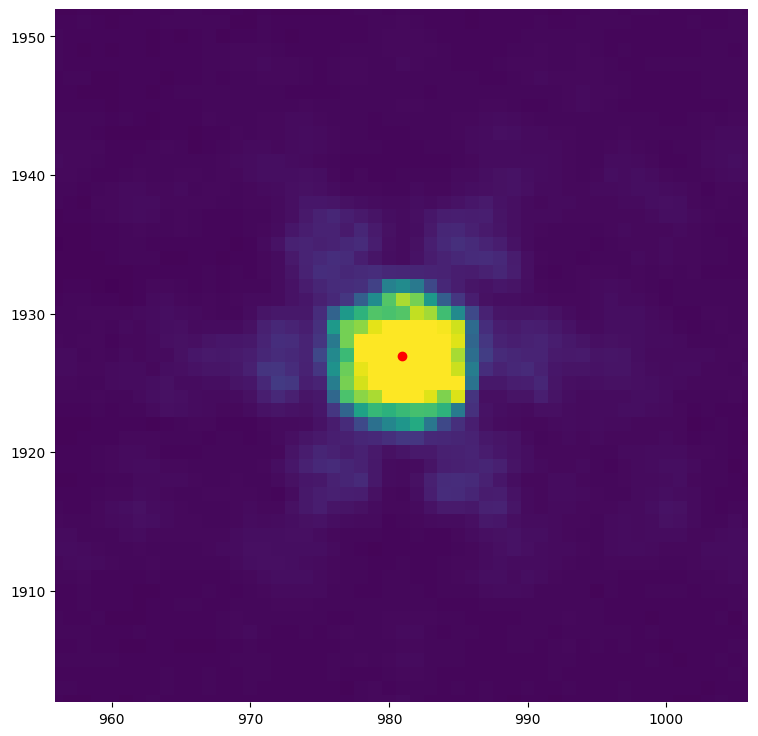

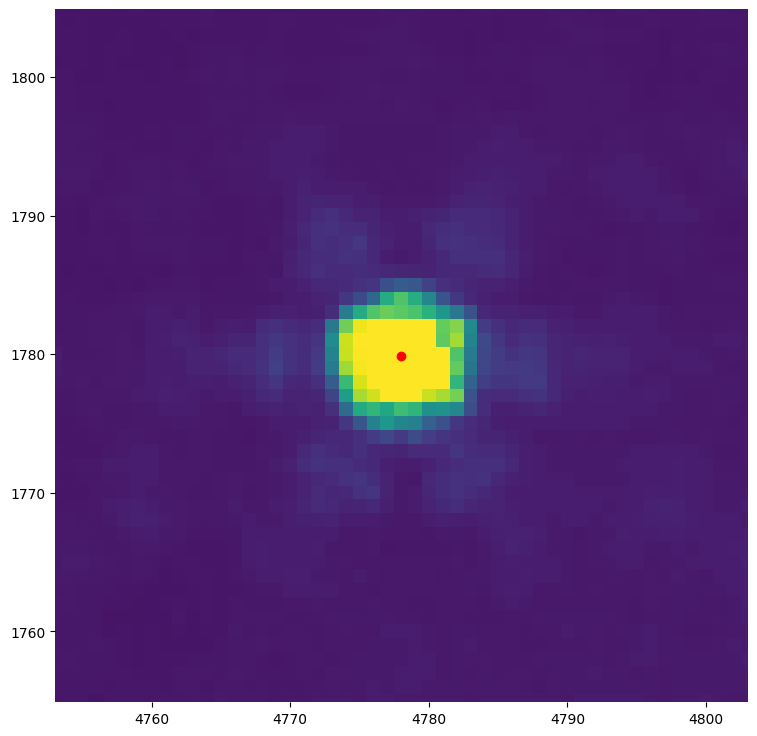

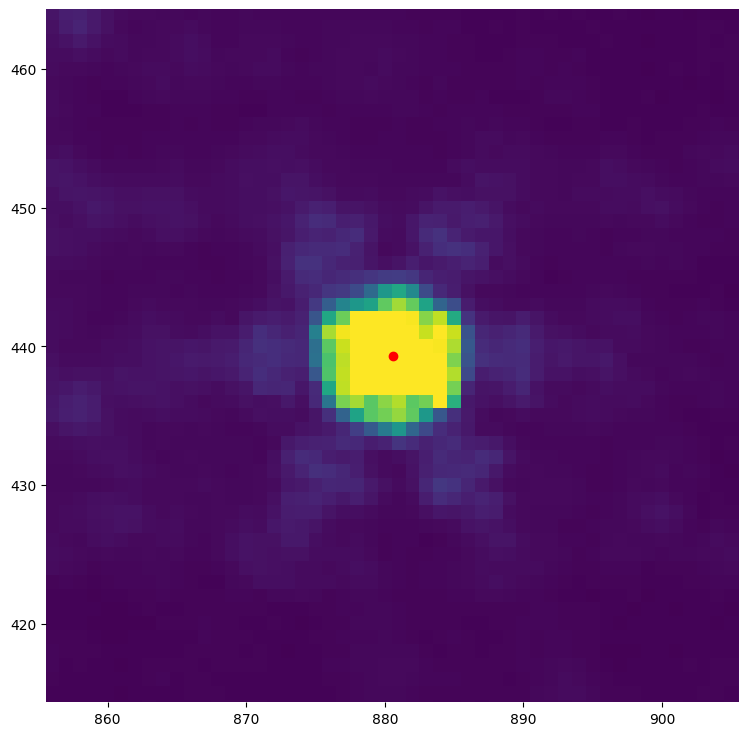

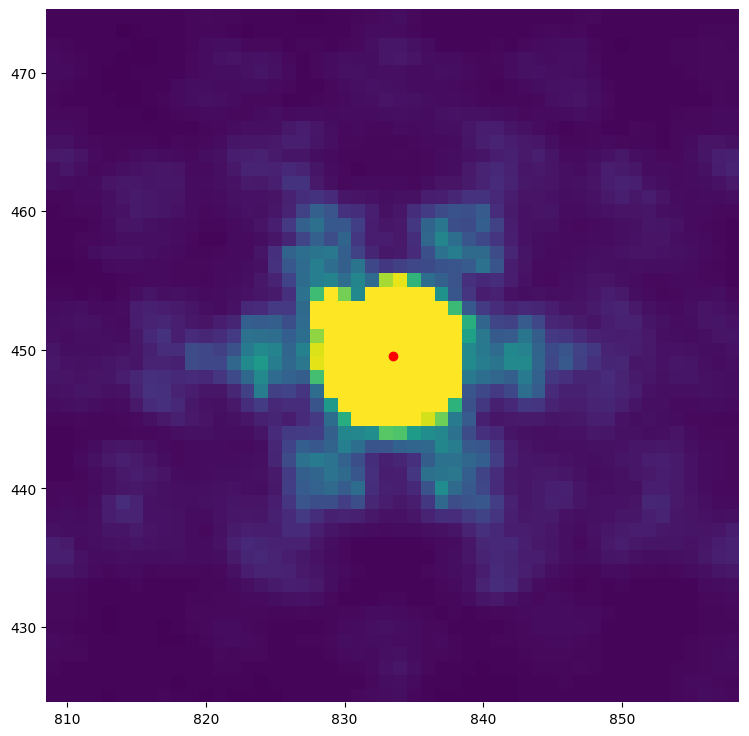

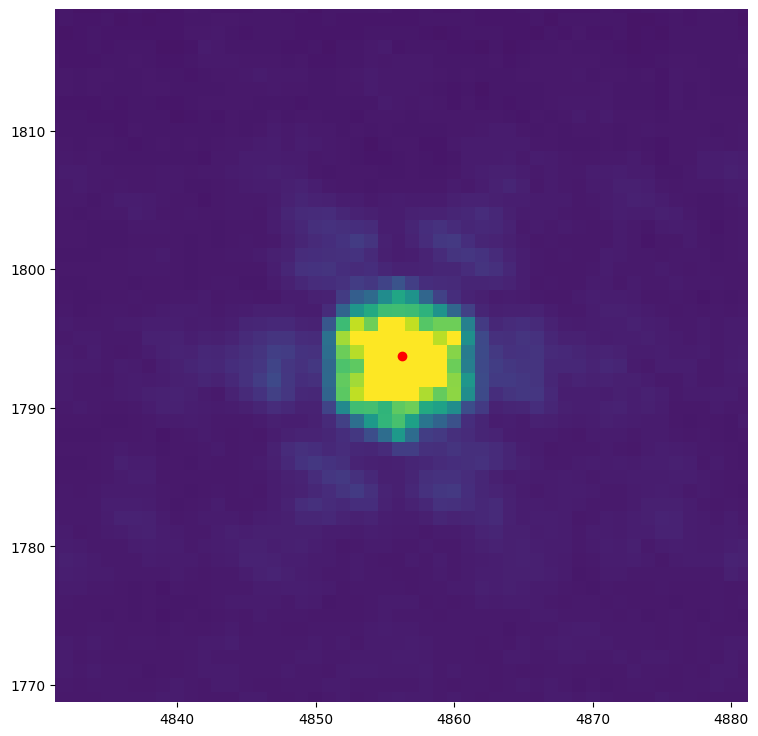

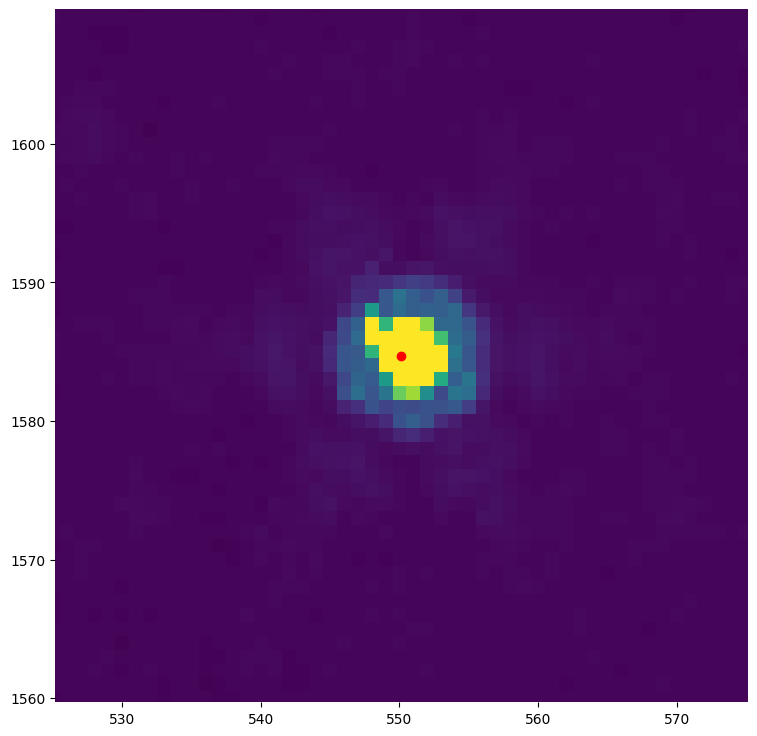

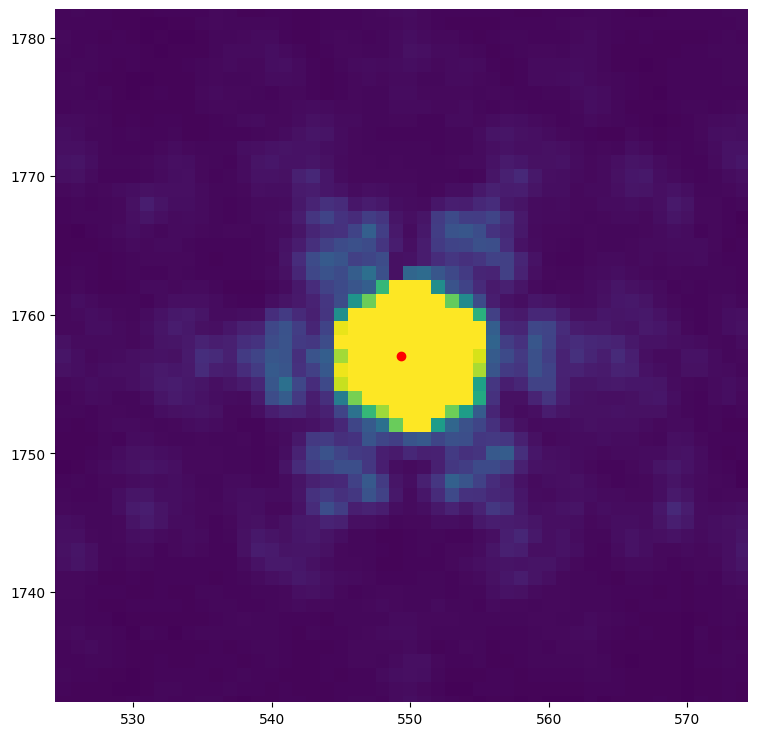

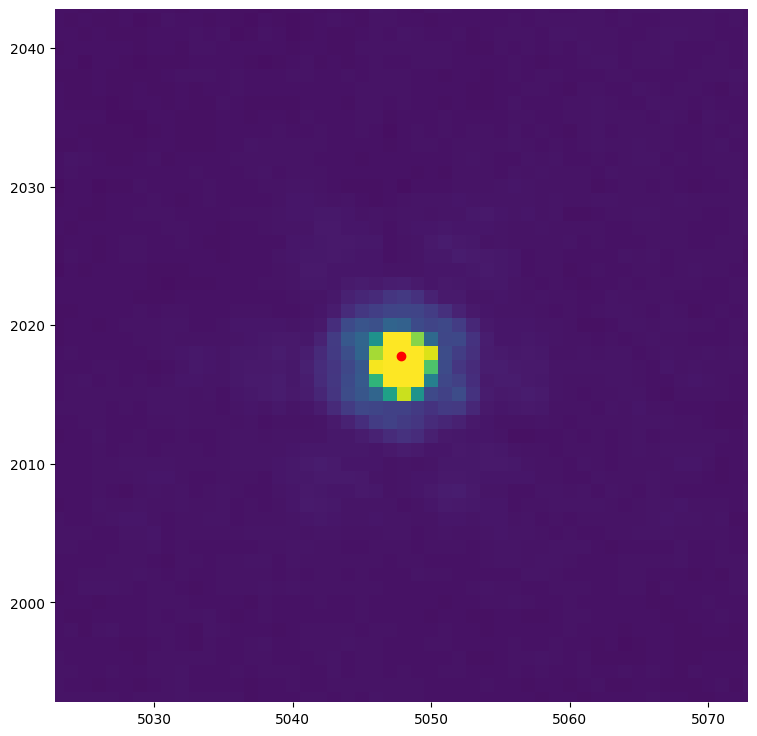

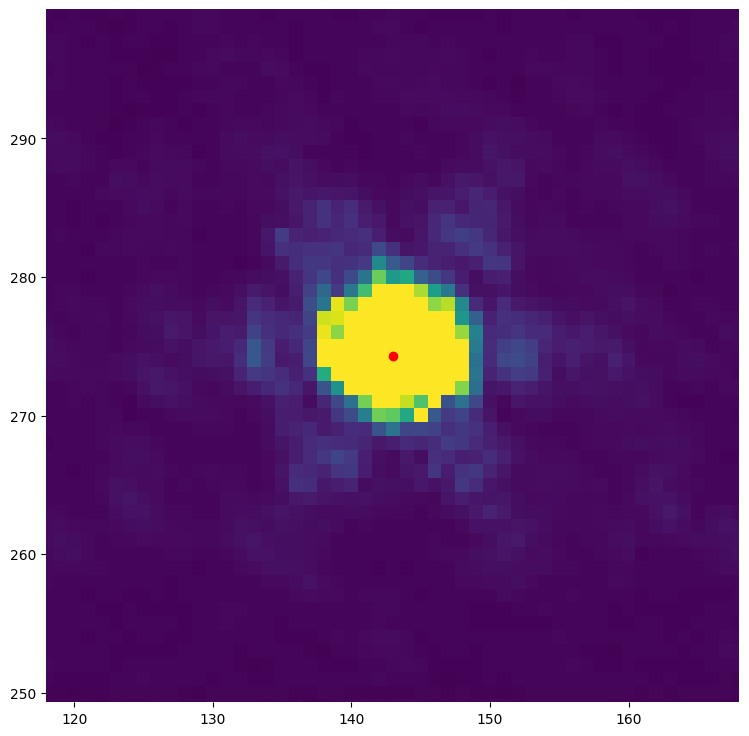

In [14]:
star_check(image, header, l)